In [1]:
import os
from typing import List, Dict


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X_train = pd.read_csv("../data/training/X_train.csv")
y_train = pd.read_csv("../data/training/y_train.csv")
print(f"Shape of X_train : {X_train.shape} and y_train : {y_train.shape}")

Shape of X_train : (3266, 2053) and y_train : (3266, 2)


In [6]:
data = pd.merge(X_train, y_train, on = "Unnamed: 0", how = "left")

In [43]:
data = pd.read_csv("../data/processed/consolidated_dataframe.csv")
exp_col_names = data.drop(['subject', 'trial', 'trail_type', 'label', 'label_description',
       'shape', 'epoch_data_ICA_inds_x', "epoch_data_ICA_inds_y", "epoch_data_ICA_inds"], axis = 1).columns

data = data.groupby(["subject","label","label_description","trial"]).agg({col_name : "mean" for col_name in exp_col_names}).reset_index()

data.to_csv("../data/processed/agg_consolidated_dataframe.csv", index = False)

In [25]:
channel_info = pd.read_csv("../data/analysis/ChannelInformationInfo.csv")

region_of_interest = {
    "Region1": ["Fc1.", "Fc2.", "Fc3.", "Fc4.", "Fc5.", "Fc6."], 
    "Region2": ["C5..", "C6..", "C3..", "C4..","C1..", "C2.."],
    "Region3": ["Cp1.", "Cp2.", "Cp3.", "Cp4.", "Cp5.", "Cp6."], 
    "Region4": ["Fc3.", "Fc4.", "C5..", "C6..", "C3..", "C4..", "C1..", "C2..", "Cp3.", "Cp4."], 
    "Region5": ["Fc1.", "Fc2.", "Fc3.", "Fc4.", "Cp1.", "Cp2.", "Cp3.", "Cp4.", "C1..", "C2..", "C3..", "C4.."]
}


#### Viz 1 : Distribution of T1 vs T2

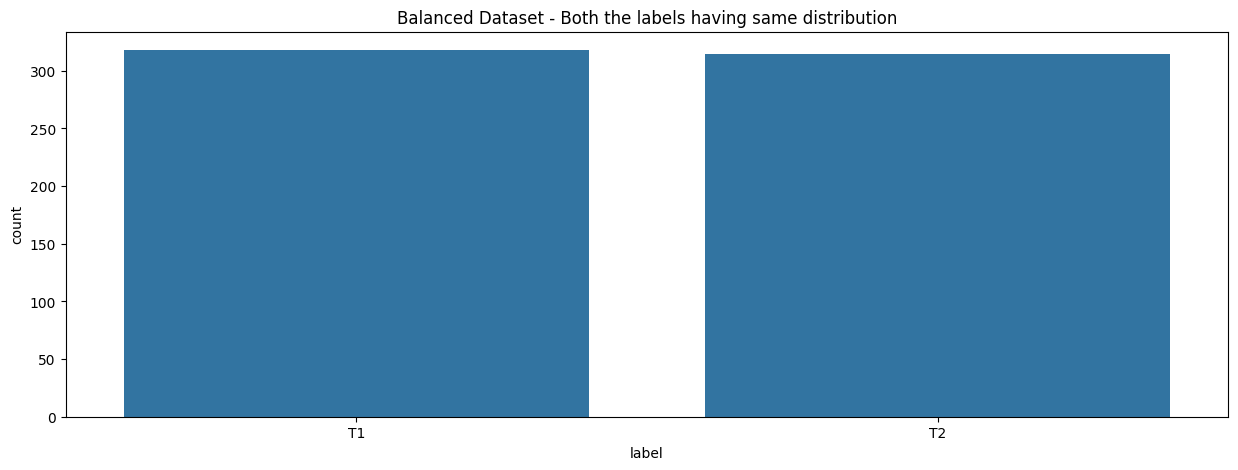

In [26]:
plt.figure(figsize= (15, 5))
sns.barplot(data["label"].value_counts())
plt.title("Balanced Dataset - Both the labels having same distribution")
plt.show()

#### Viz 2 : Region 1

In [35]:
def plot_distributions(data, cols_conc, nrows=4, ncols=4):
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 15))
    axes = axes.flatten()

    for k, col in enumerate(cols_conc[:-1]):  # last column is for hue
        ax = axes[k]
        sns.histplot(data=data, x=col, hue=cols_conc[-1], element="step", ax=ax)
        ax.set_title(f"Dist : {col}")

    # Hide any unused subplots
    for ax in axes[len(cols_conc)-1:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

In [36]:
channel_info["AggType"].unique()

array(['mean', 'std', 'var', 'skew', 'kurt', 'max', 'min', 'ptp',
       'median', 'zero', 'rms', 'delta', 'theta', 'alpha', 'beta',
       'gamma', 'total', 'centroid', 'spread', 'entropy', 'peak', 'amp',
       'freq', 'wavelet'], dtype=object)

#### Viz 2.1 : Joint - Related Feature Category

=========================== Joint - Region 1 - amp =============================


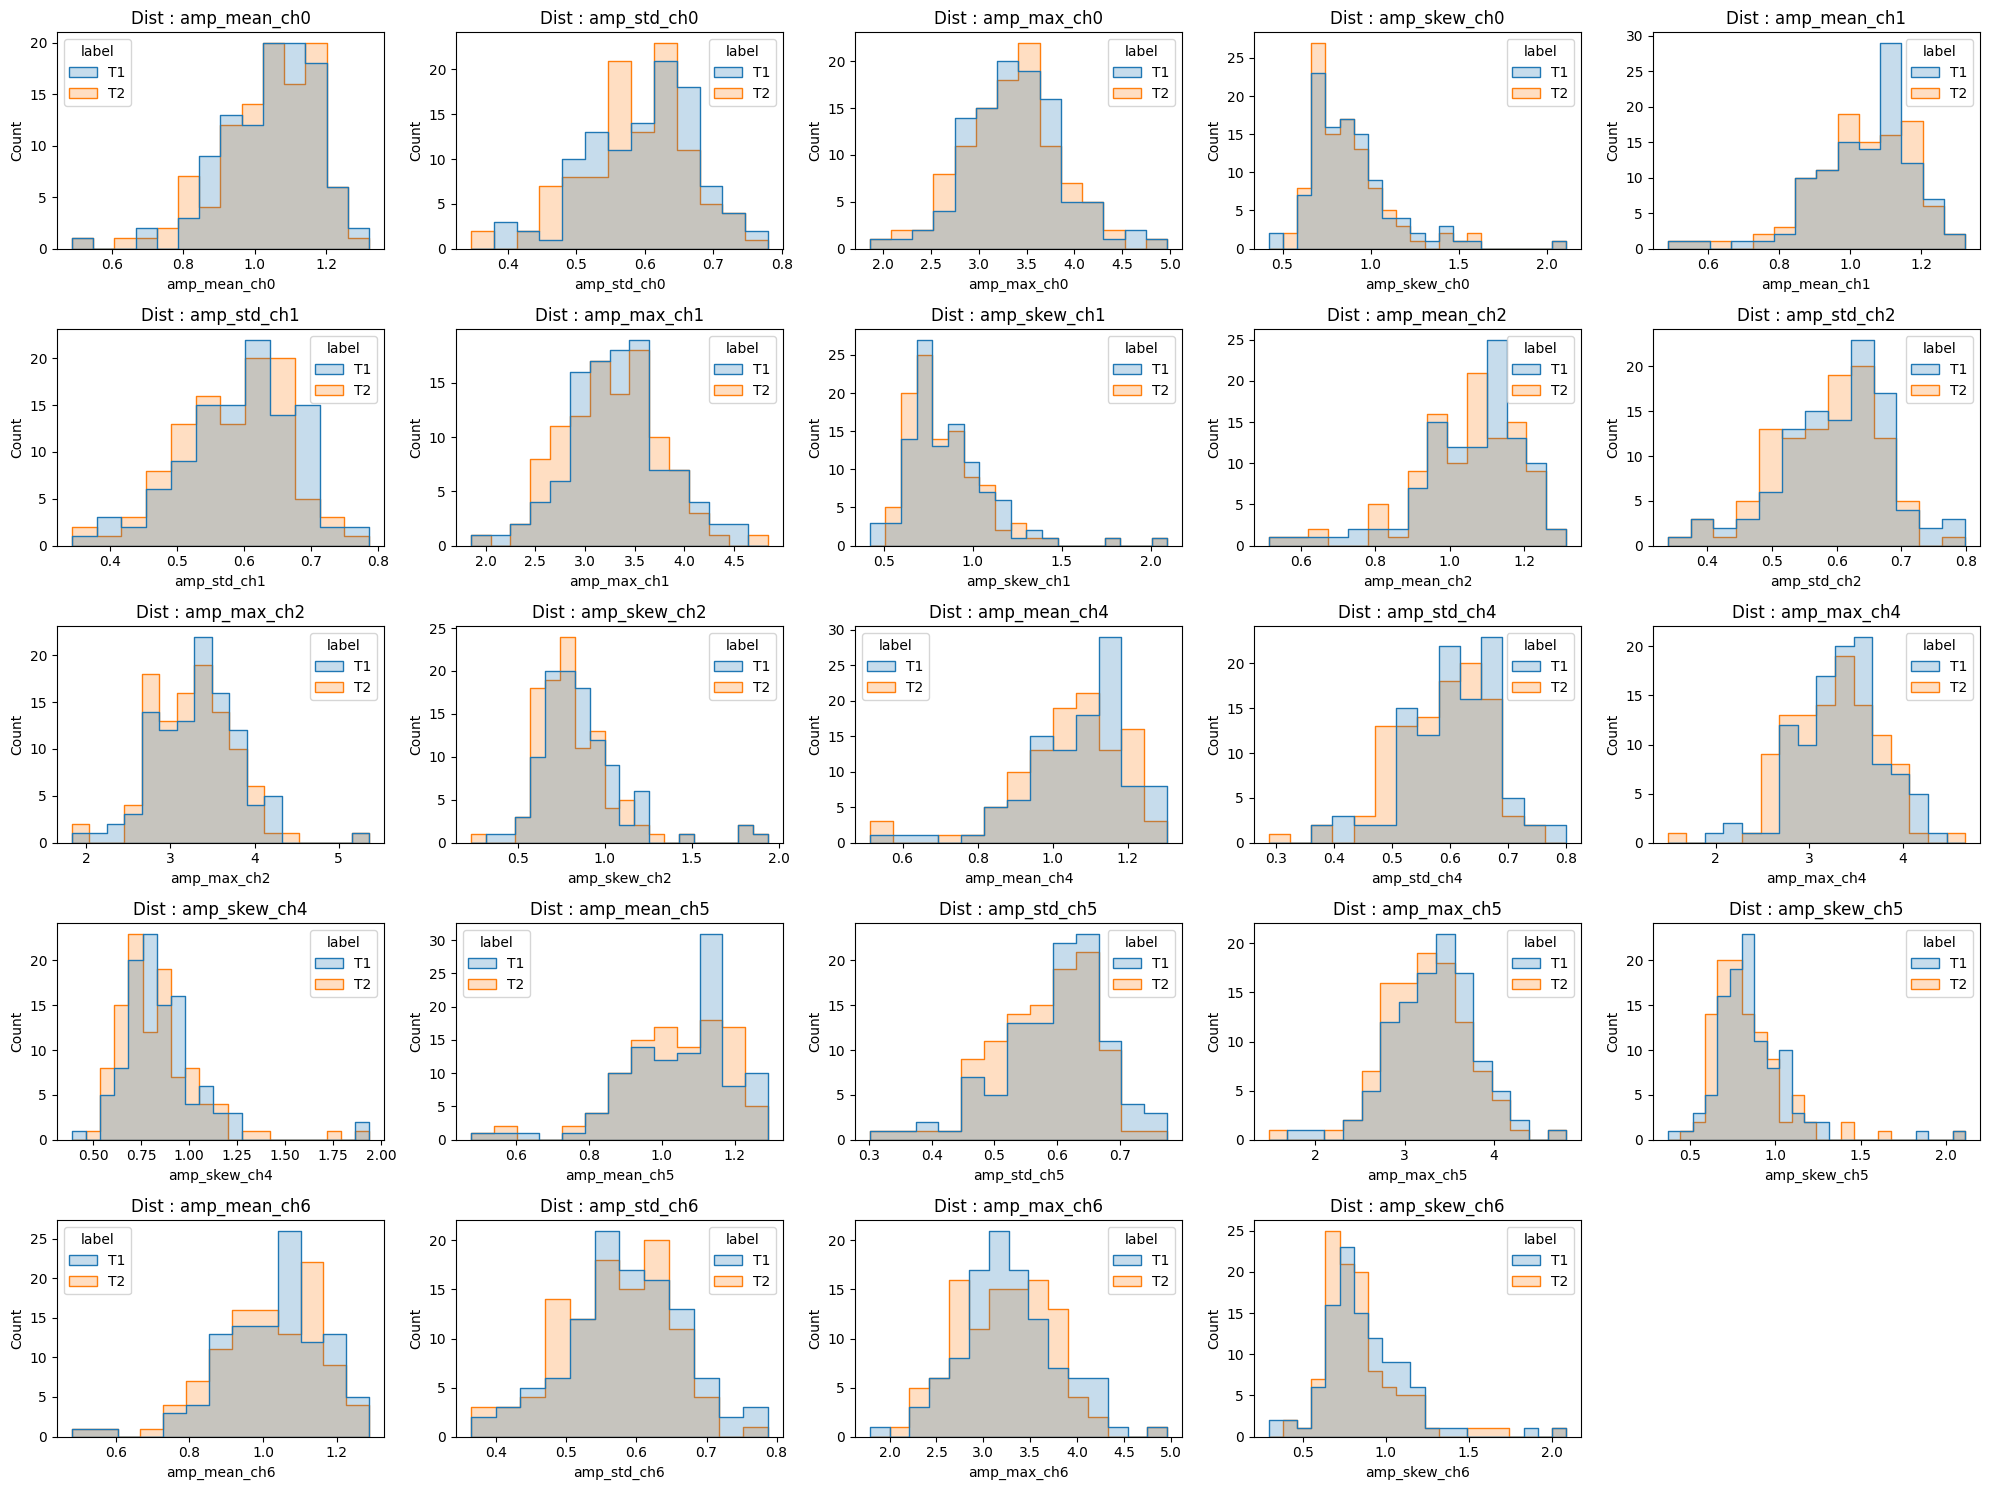

=========================== Joint - Region 1 - freq =============================


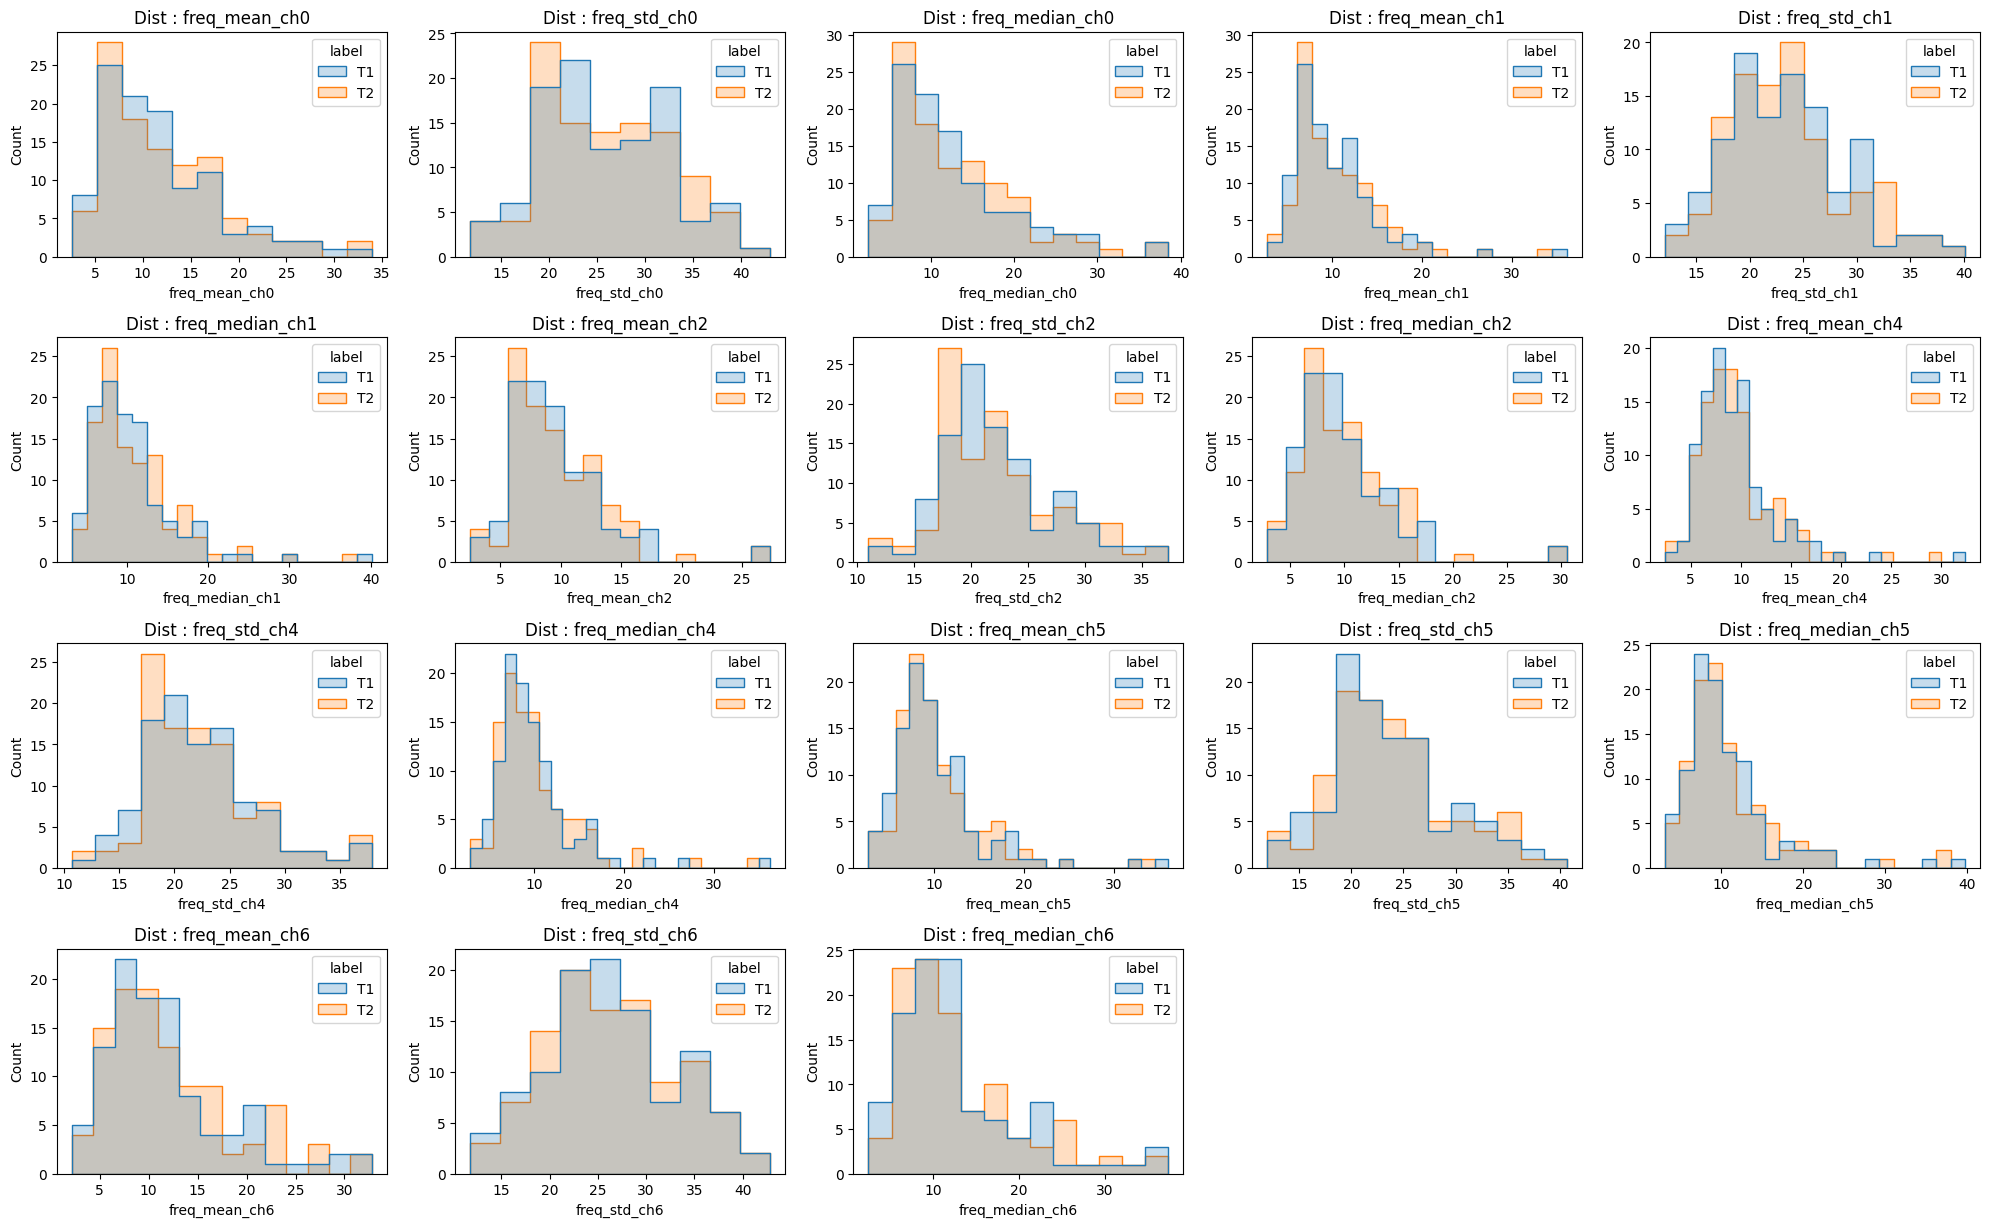

=========================== Joint - Region 1 - wavelet =============================


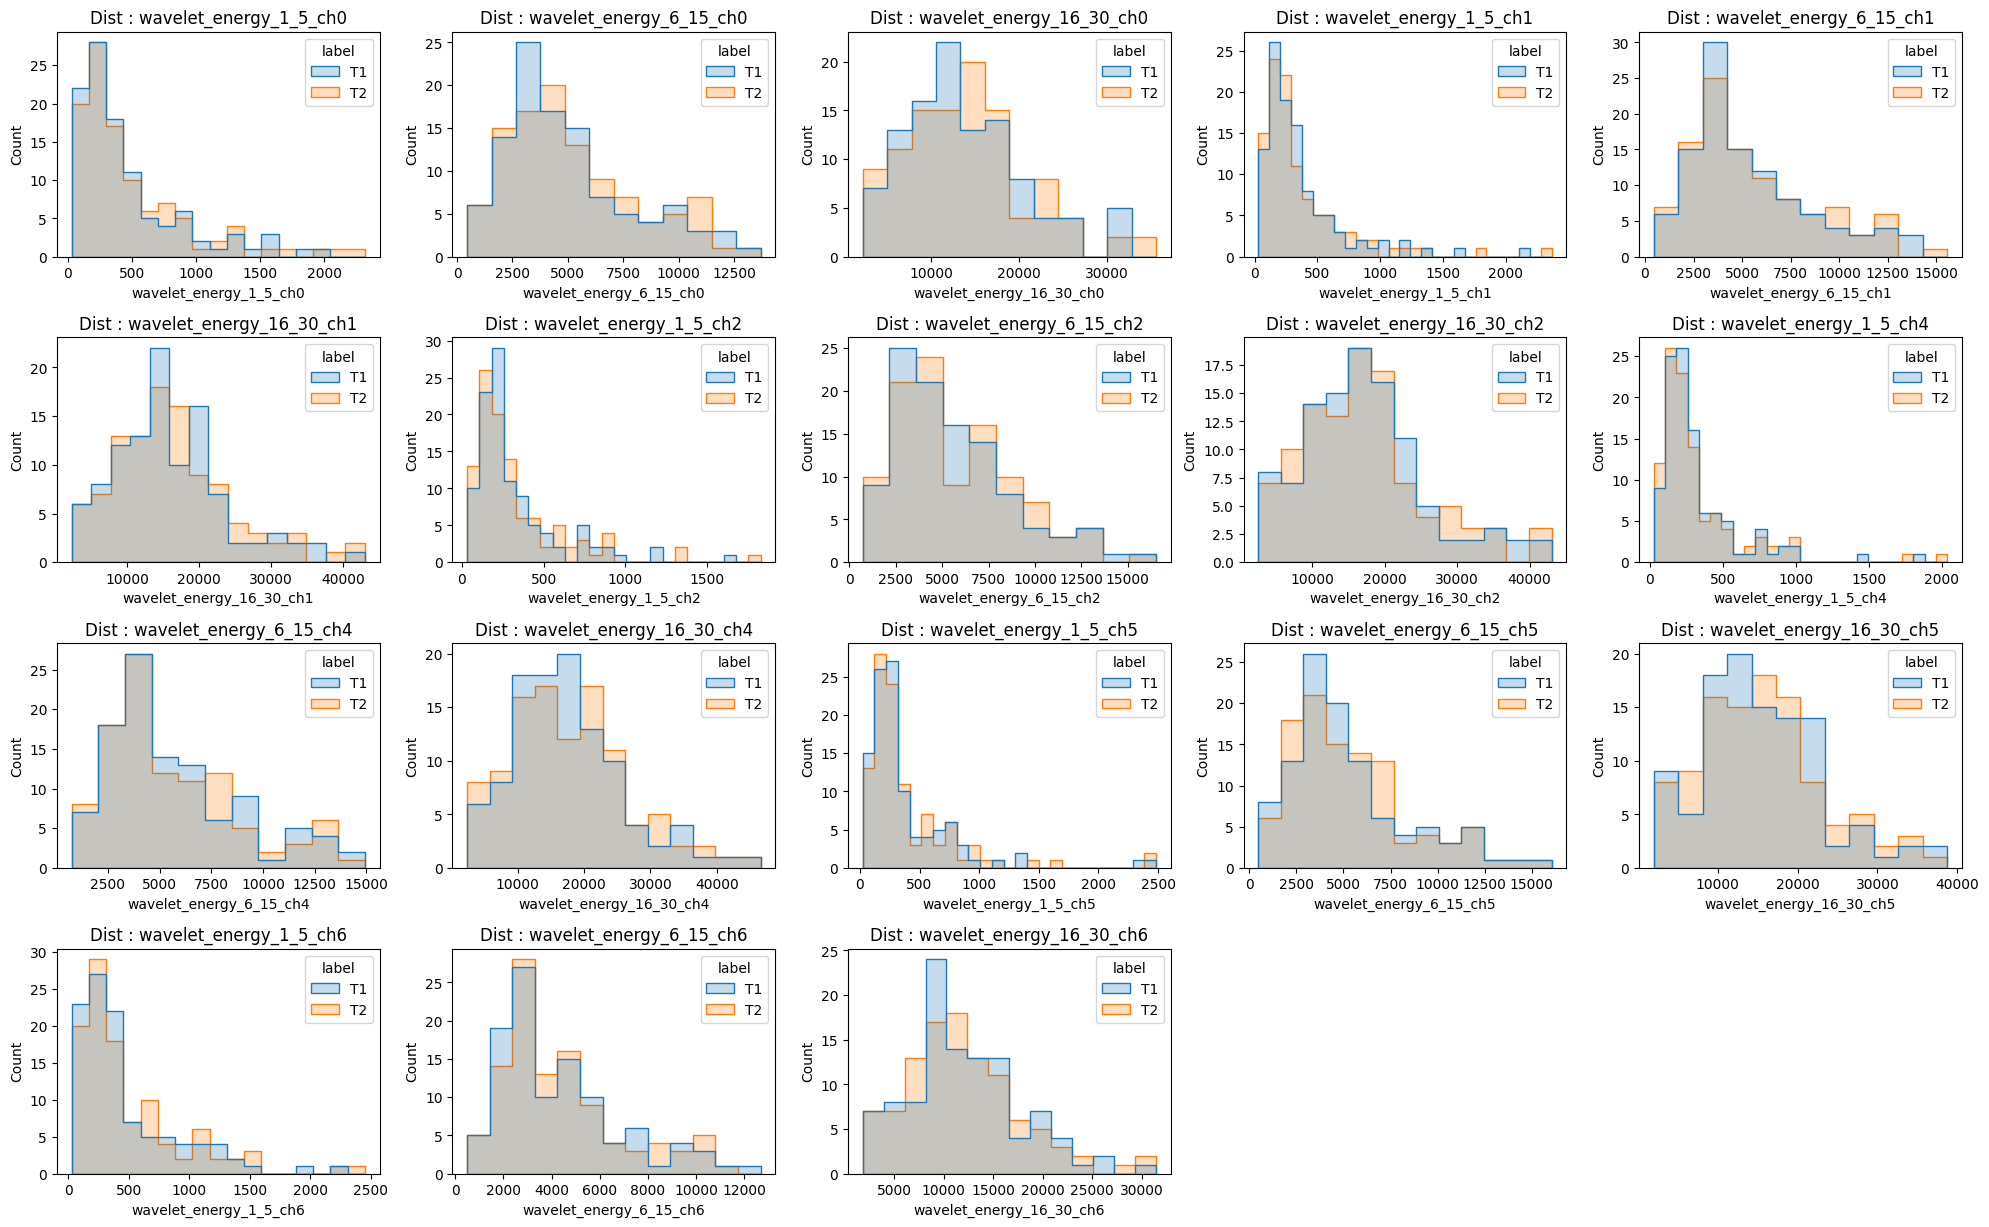

In [37]:
joint_agg_type = channel_info[channel_info["FeatureCategory"].isin(["Joint"])]["AggType"].unique().tolist()
for i in joint_agg_type:
    feature_category = ["Joint"]
    region_focus = region_of_interest["Region1"]
    agg = [i]
    cols_conc = (channel_info[(channel_info["FeatureCategory"].isin(feature_category)) &
                                (channel_info["AggType"].isin(agg)) &
        (channel_info["Region"].isin(region_focus))]["ColumnNames"].to_list())
    cols_conc = cols_conc + ["label"]
    print(f"=========================== Joint - Region 1 - {i} =============================")
    plot_distributions(data = data, cols_conc= cols_conc, nrows= 5, ncols=5)
    plt.show()
    

#### Viz 2.2 : Time - Related Feature Category

=========================== Joint - Region 1 - mean =============================


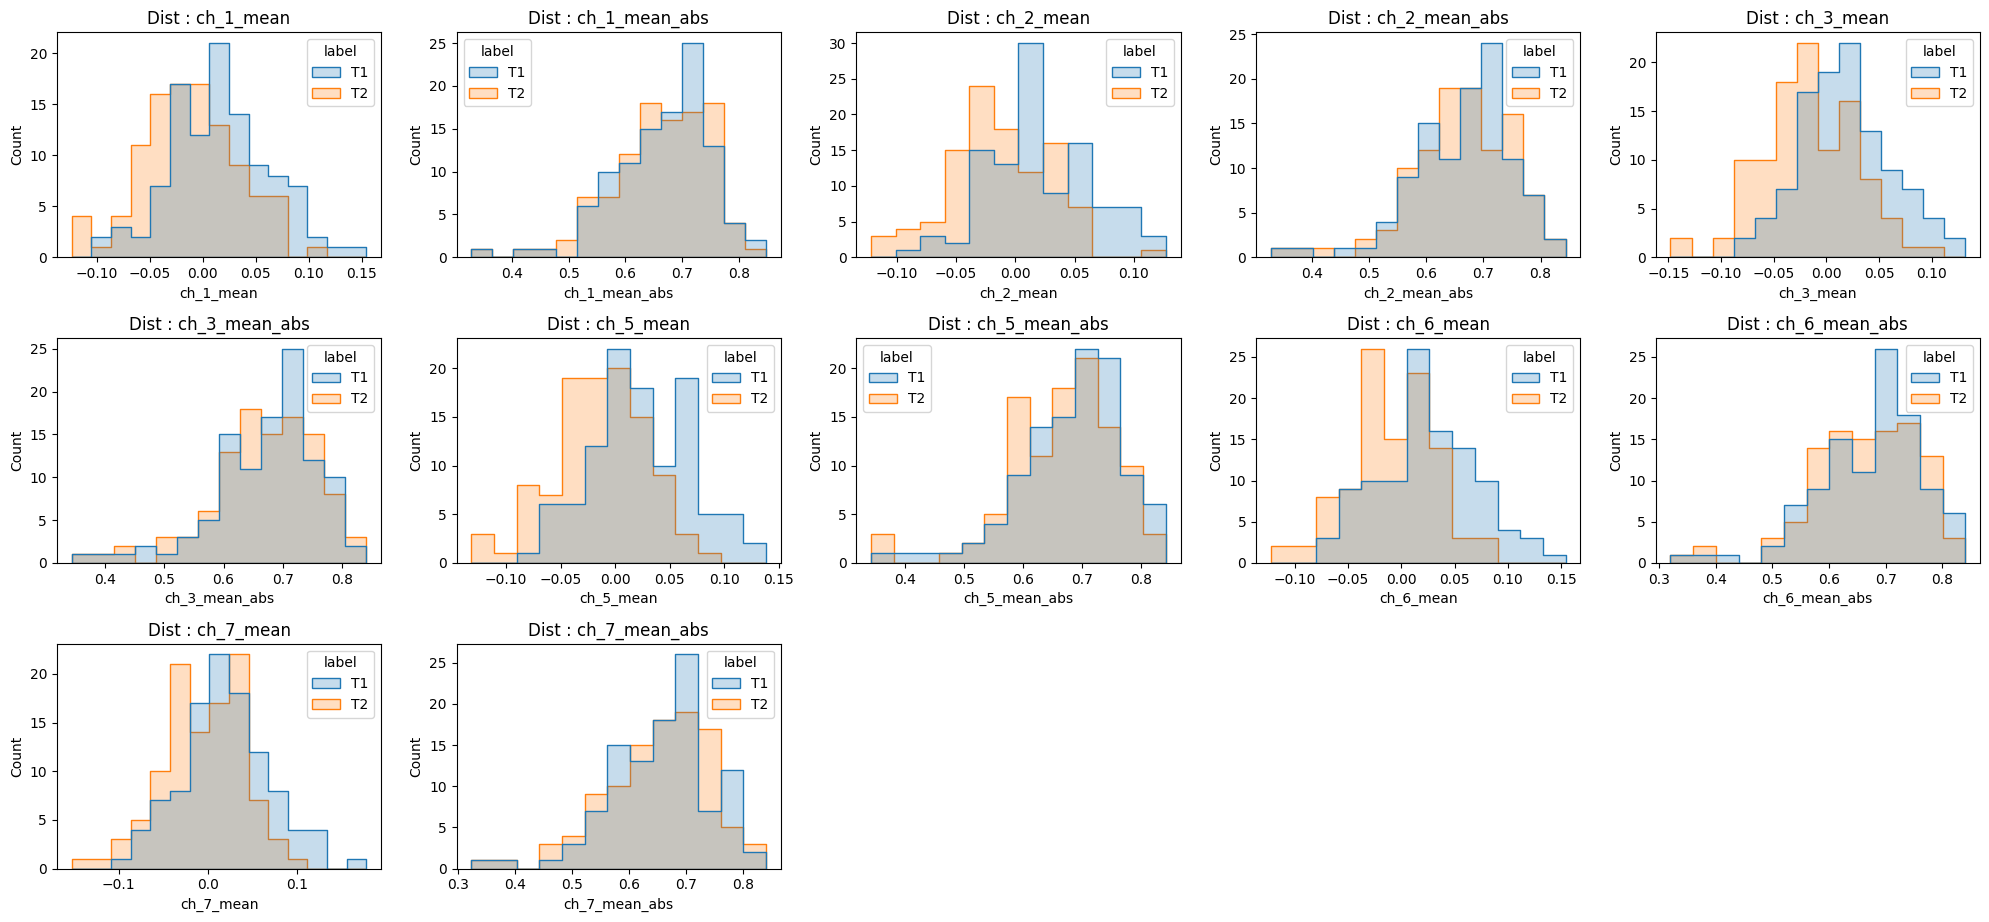

=========================== Joint - Region 1 - std =============================


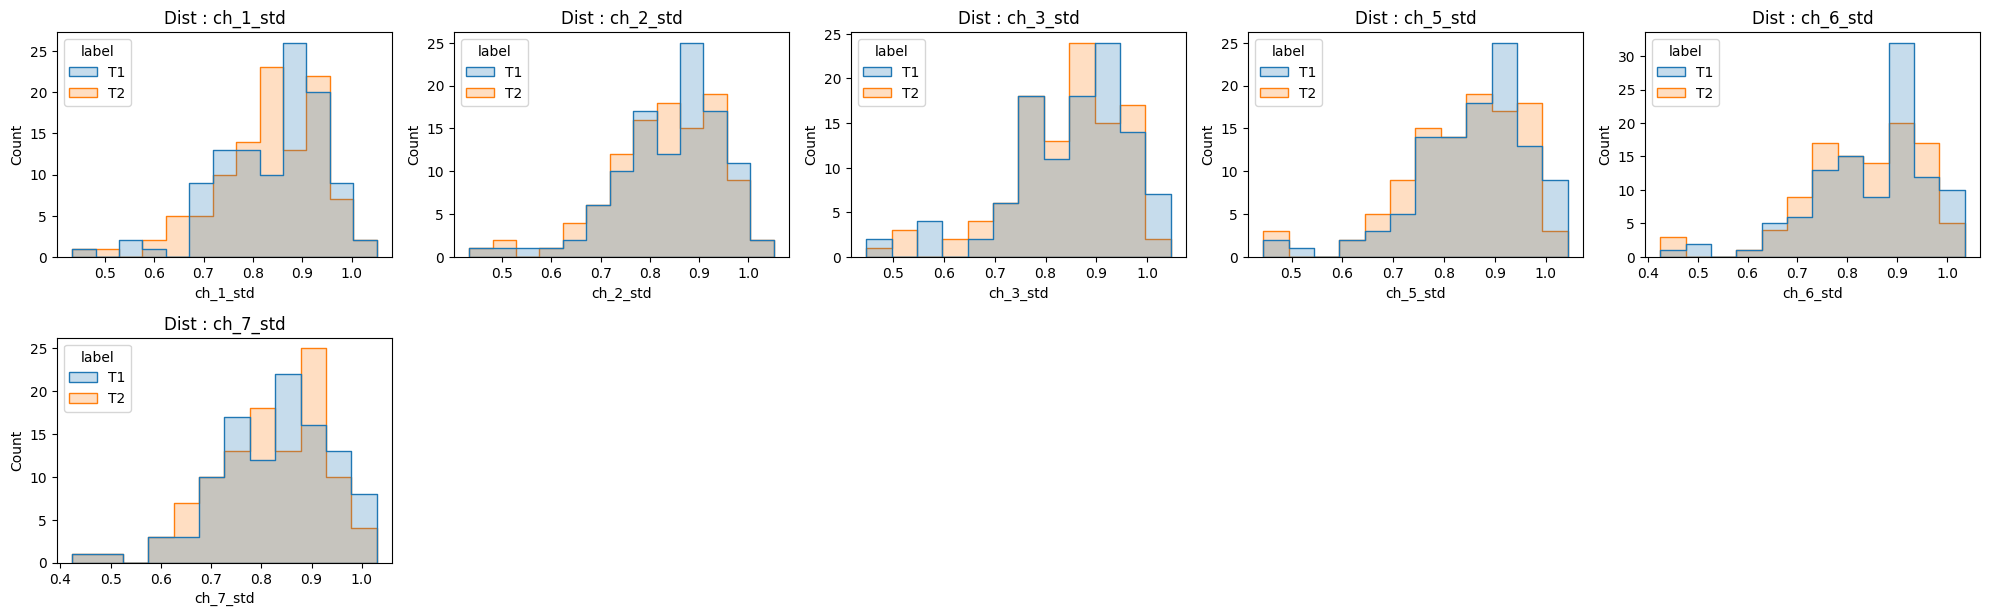

=========================== Joint - Region 1 - var =============================


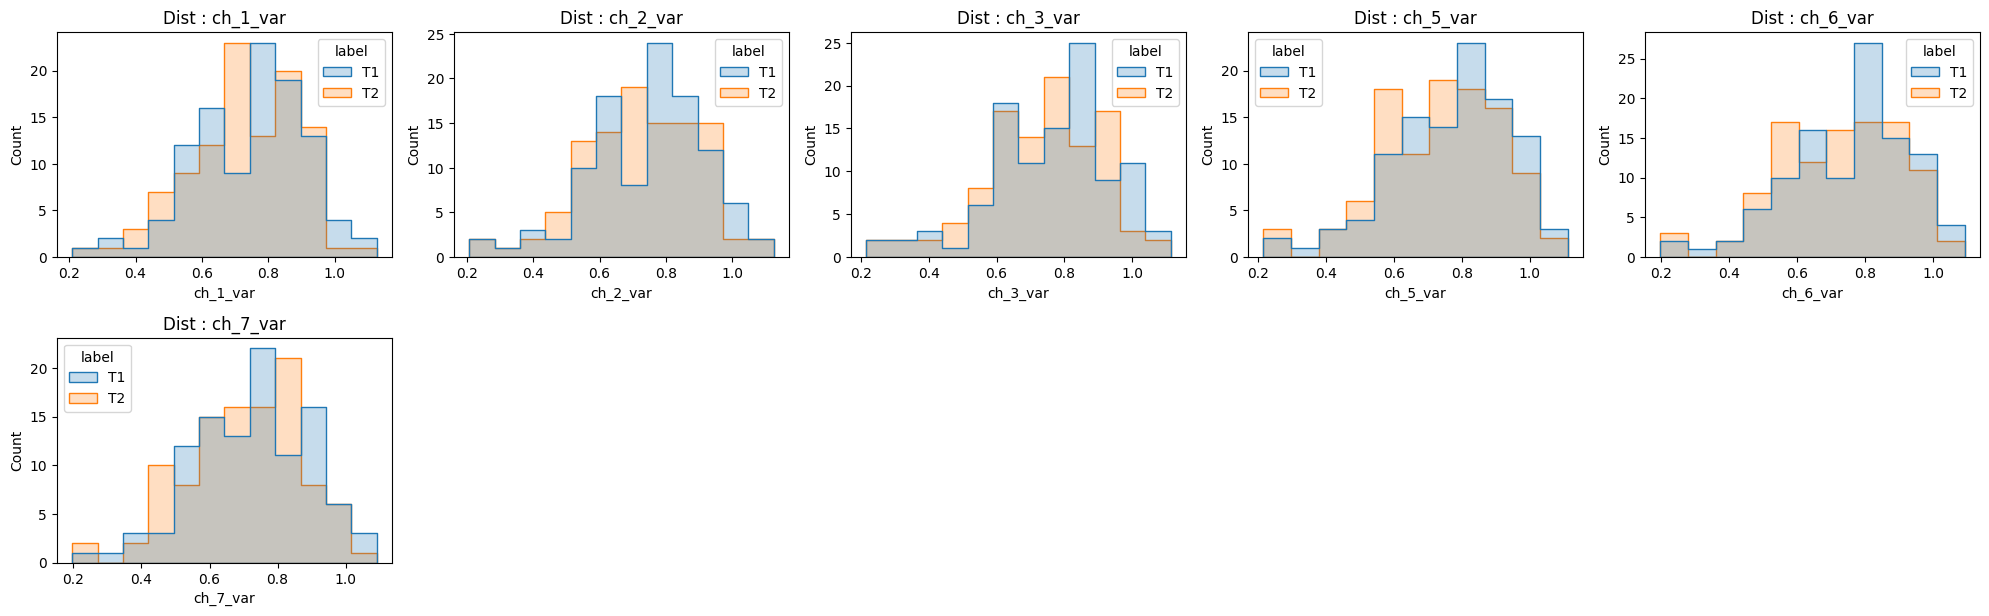

=========================== Joint - Region 1 - skew =============================


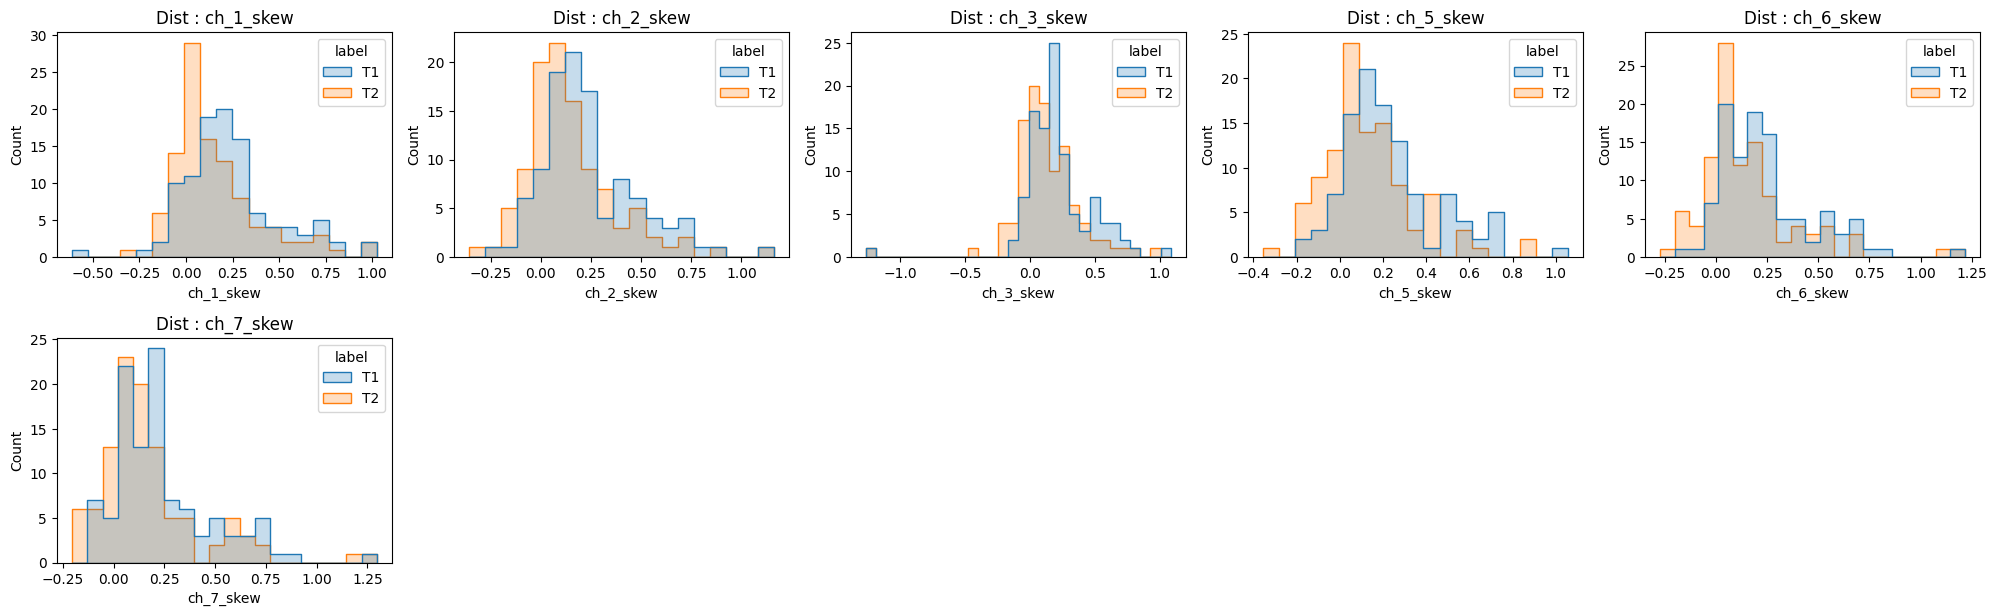

=========================== Joint - Region 1 - kurt =============================


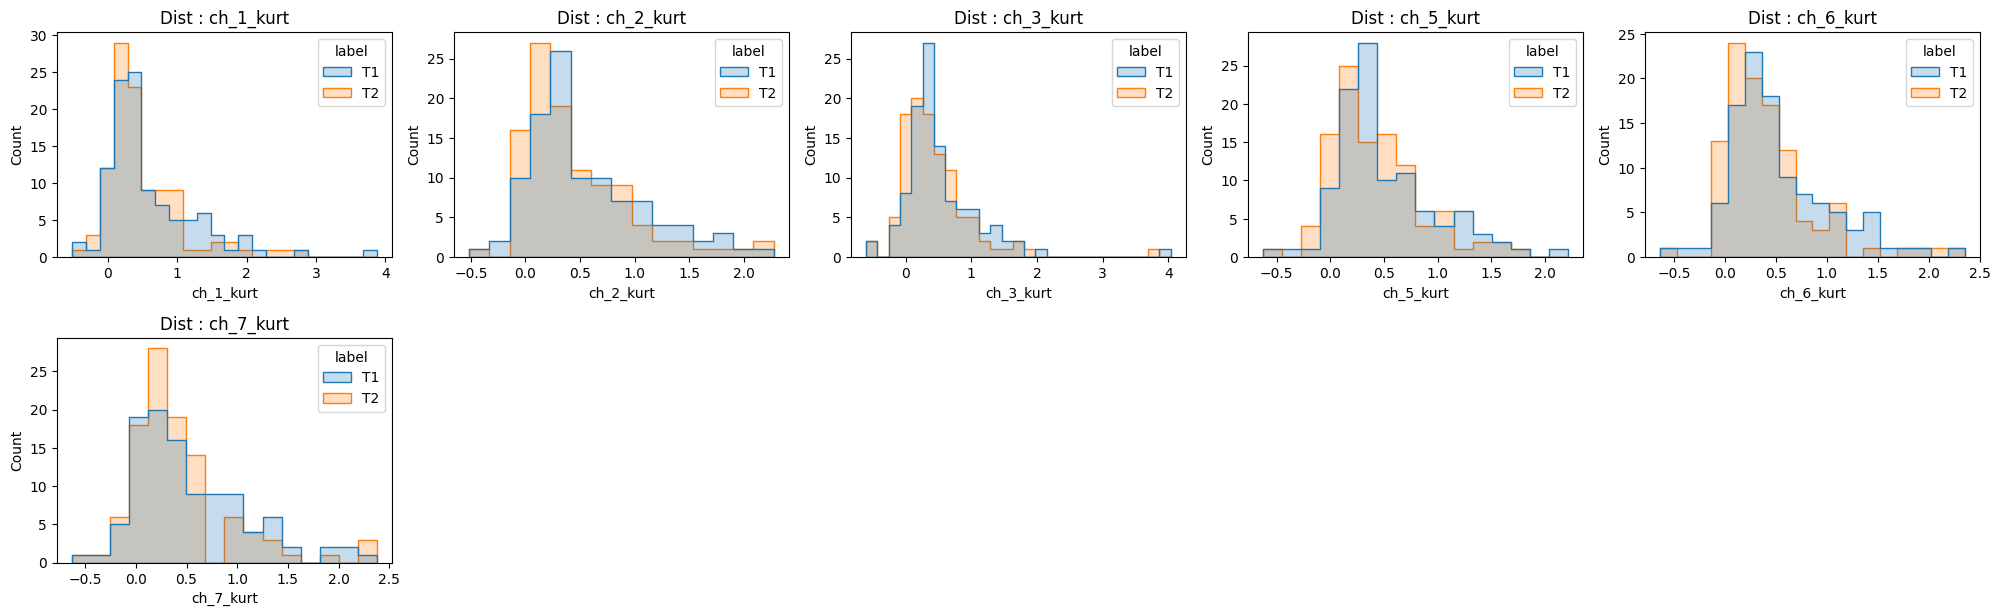

=========================== Joint - Region 1 - max =============================


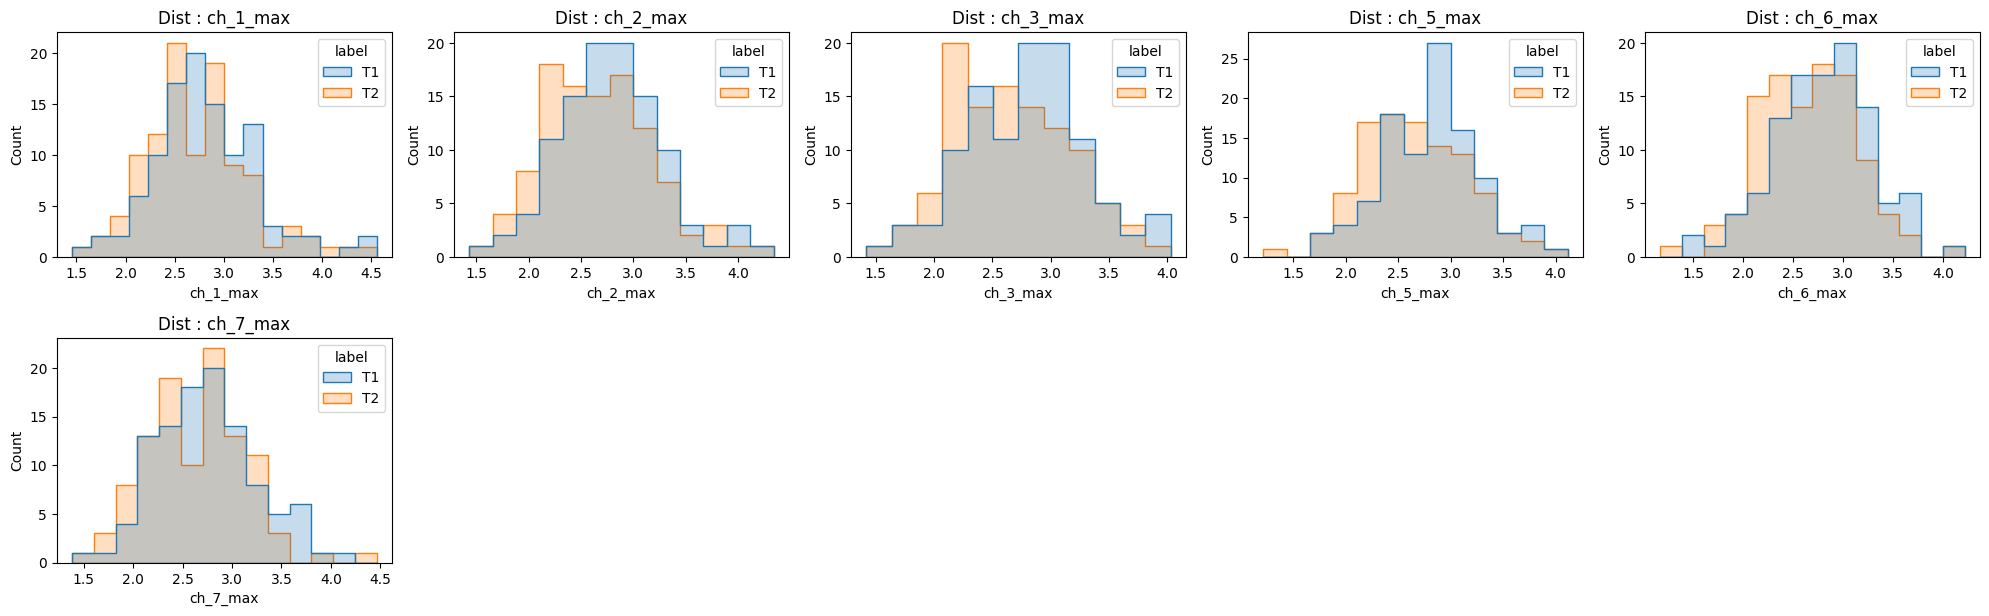

=========================== Joint - Region 1 - min =============================


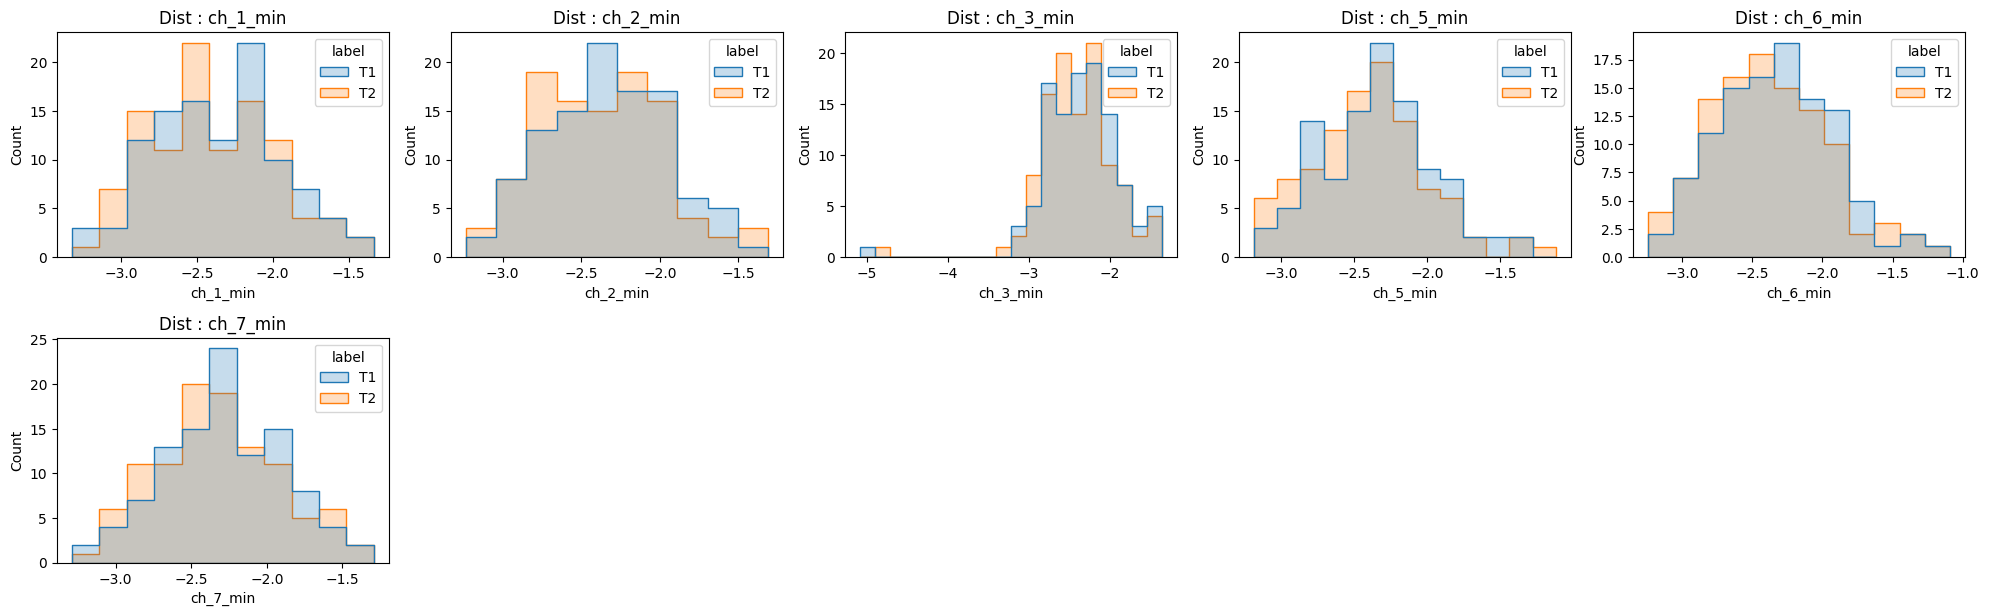

=========================== Joint - Region 1 - ptp =============================


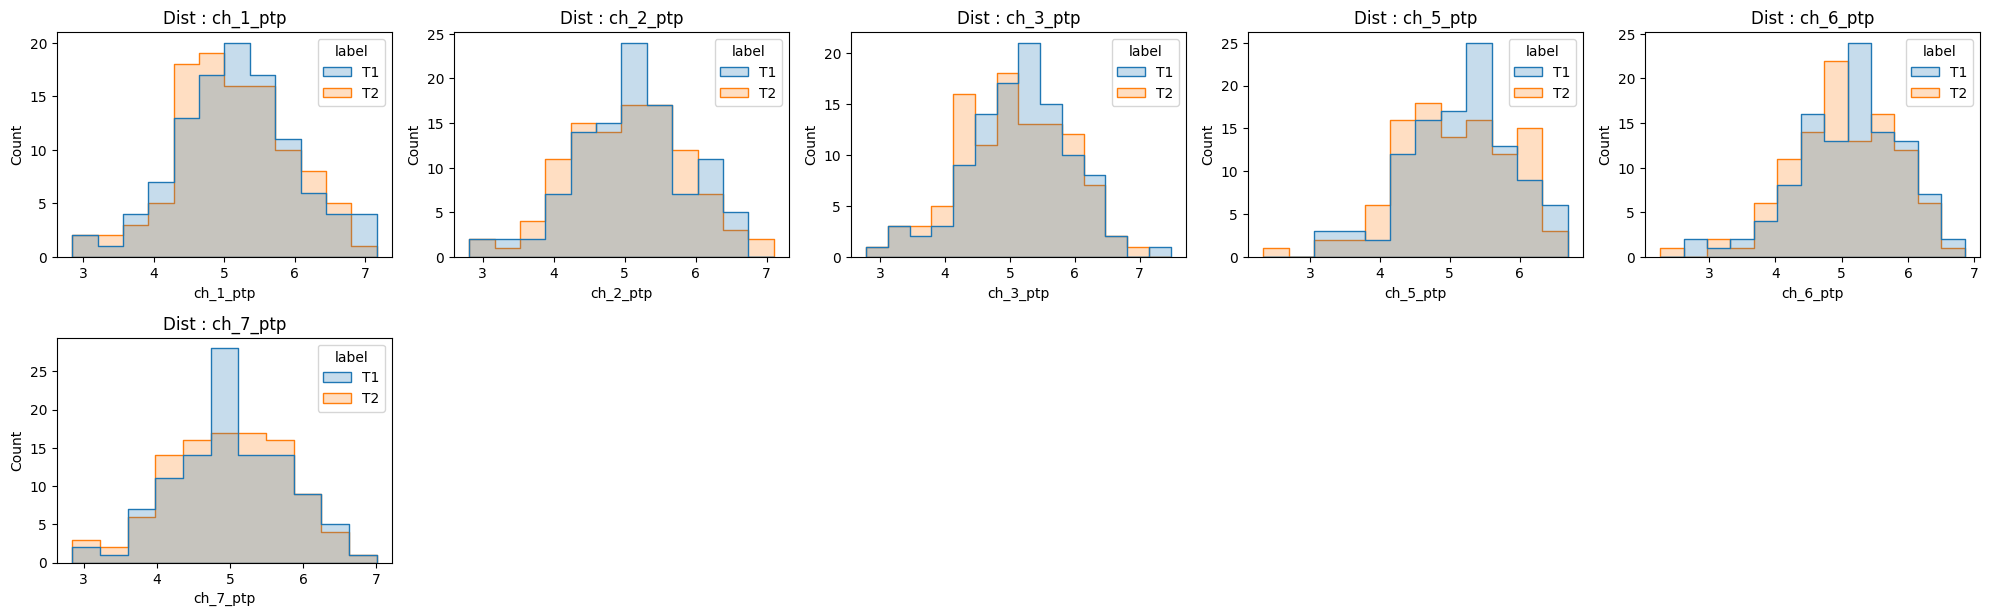

=========================== Joint - Region 1 - median =============================


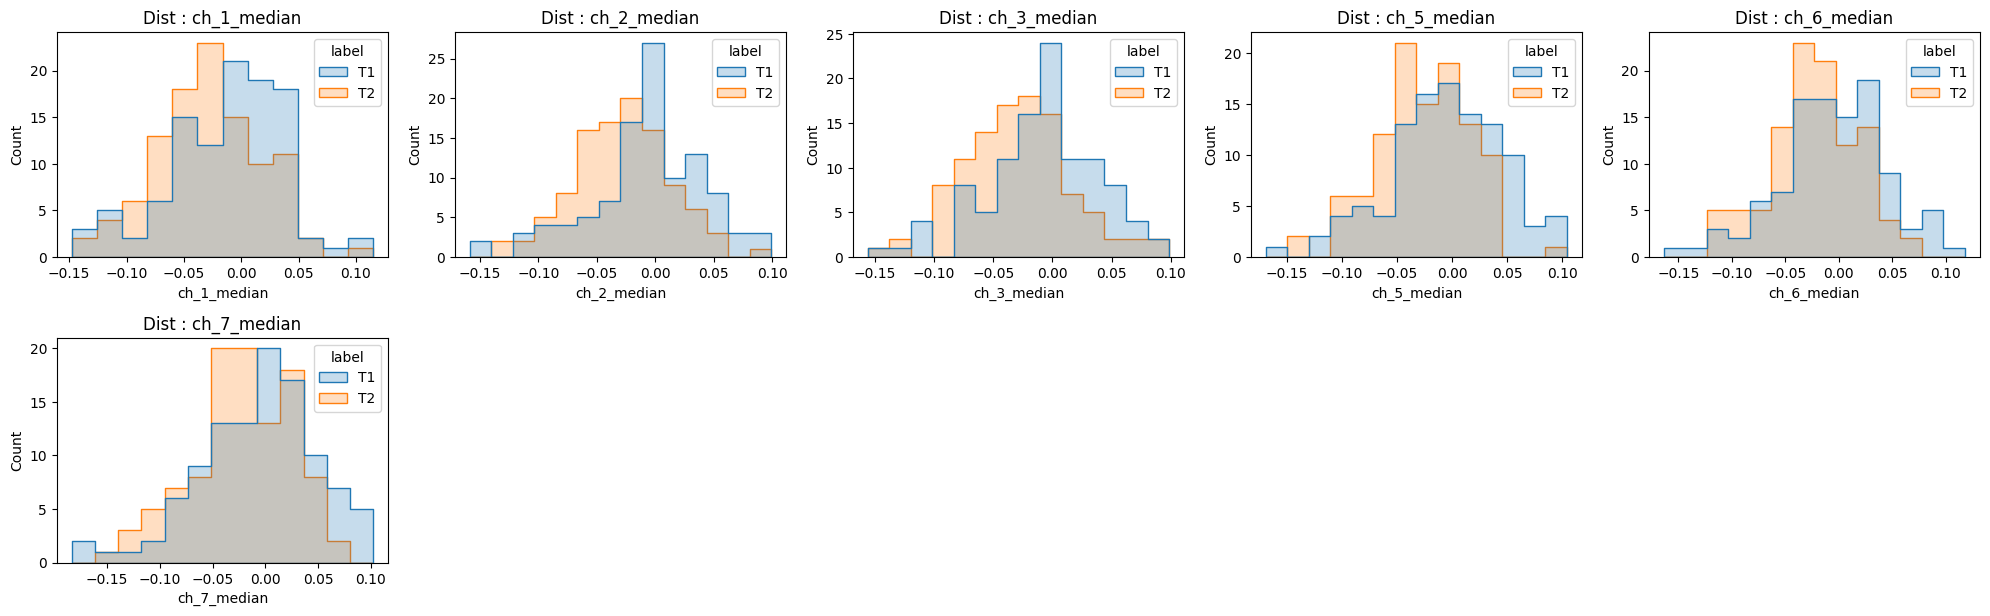

=========================== Joint - Region 1 - zero =============================


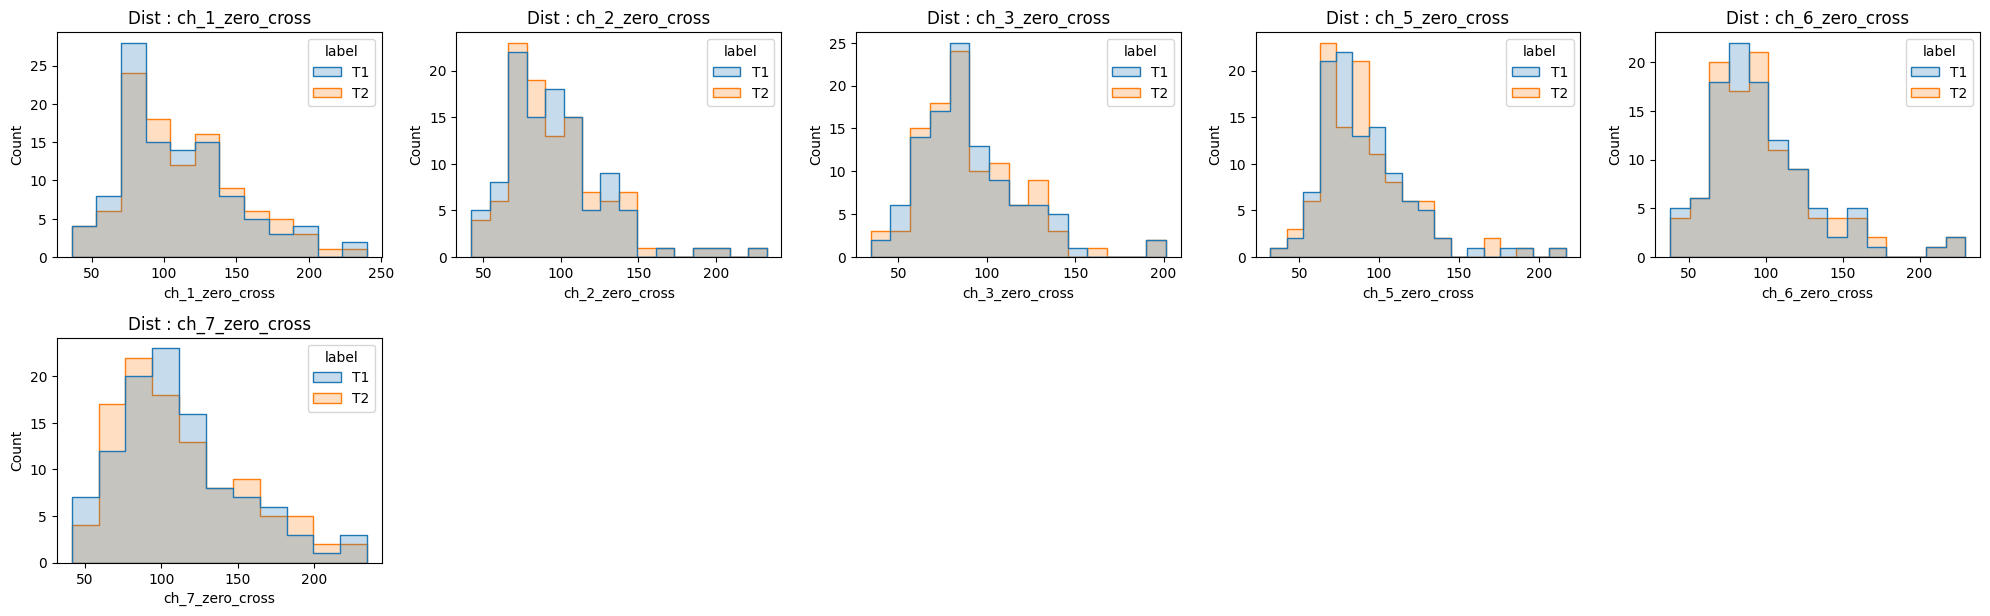

=========================== Joint - Region 1 - rms =============================


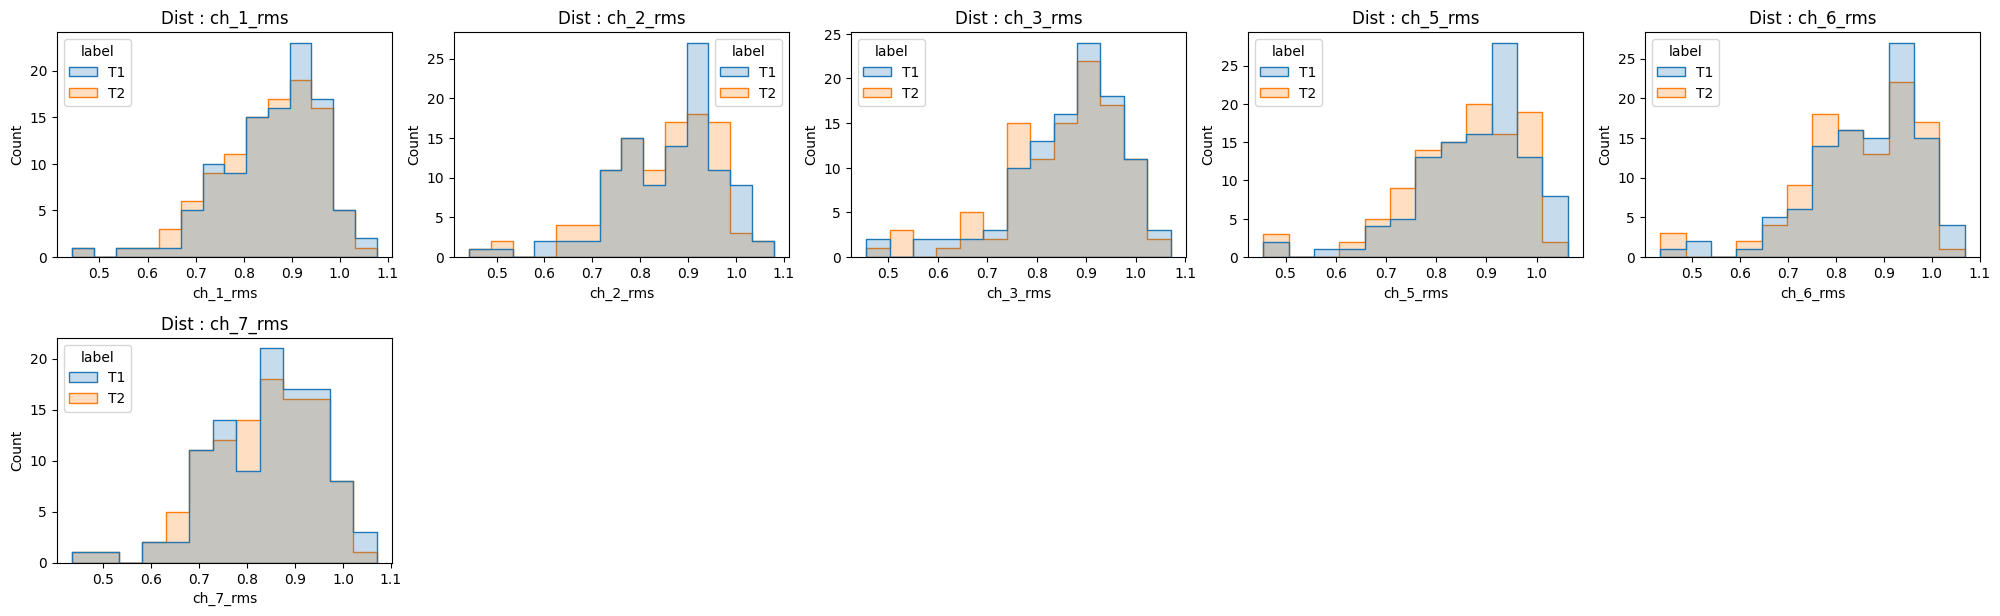

In [38]:
joint_agg_type = channel_info[channel_info["FeatureCategory"].isin(["Time"])]["AggType"].unique().tolist()
for i in joint_agg_type:
    feature_category = ["Time"]
    region_focus = region_of_interest["Region1"]
    agg = [i]
    cols_conc = (channel_info[(channel_info["FeatureCategory"].isin(feature_category)) &
                                (channel_info["AggType"].isin(agg)) &
        (channel_info["Region"].isin(region_focus))]["ColumnNames"].to_list())
    cols_conc = cols_conc + ["label"]
    print(f"=========================== Joint - Region 1 - {i} =============================")
    plot_distributions(data = data, cols_conc= cols_conc, nrows= 5, ncols=5)
    plt.show()
    

#### Viz 2.3 : Frequency - Related Feature Category

=========================== Joint - Region 1 - delta =============================


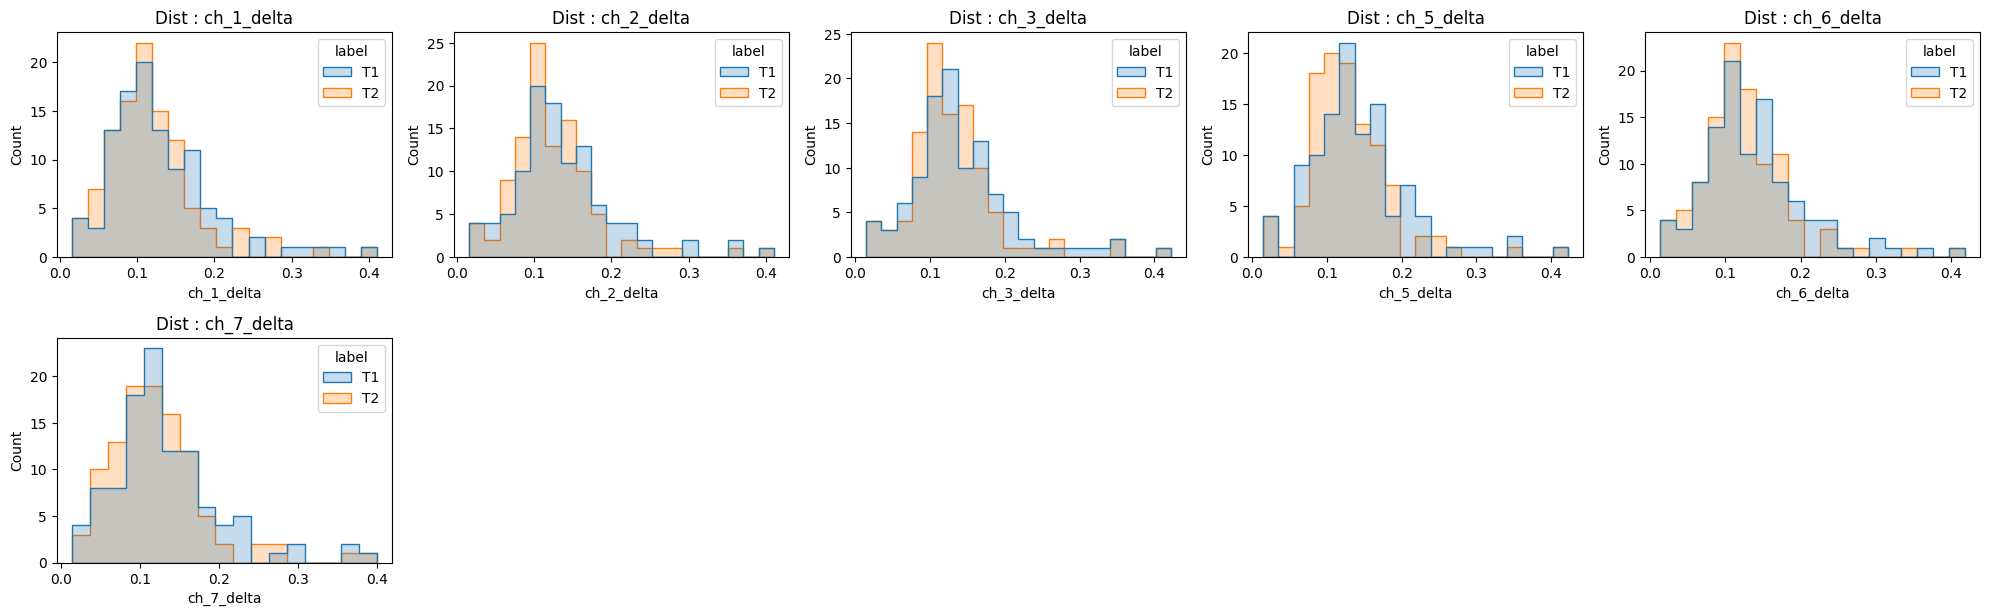

=========================== Joint - Region 1 - theta =============================


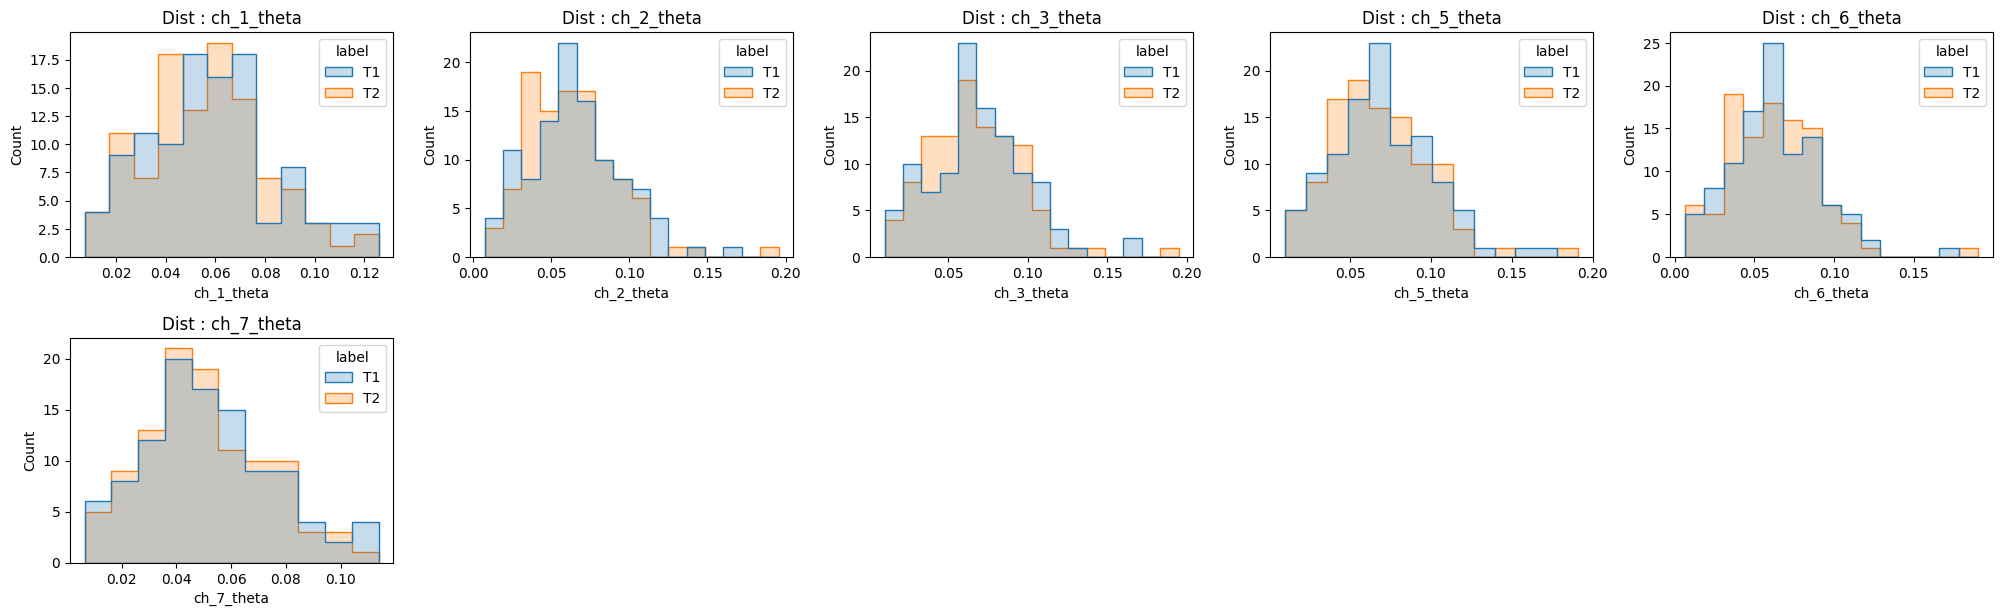

=========================== Joint - Region 1 - alpha =============================


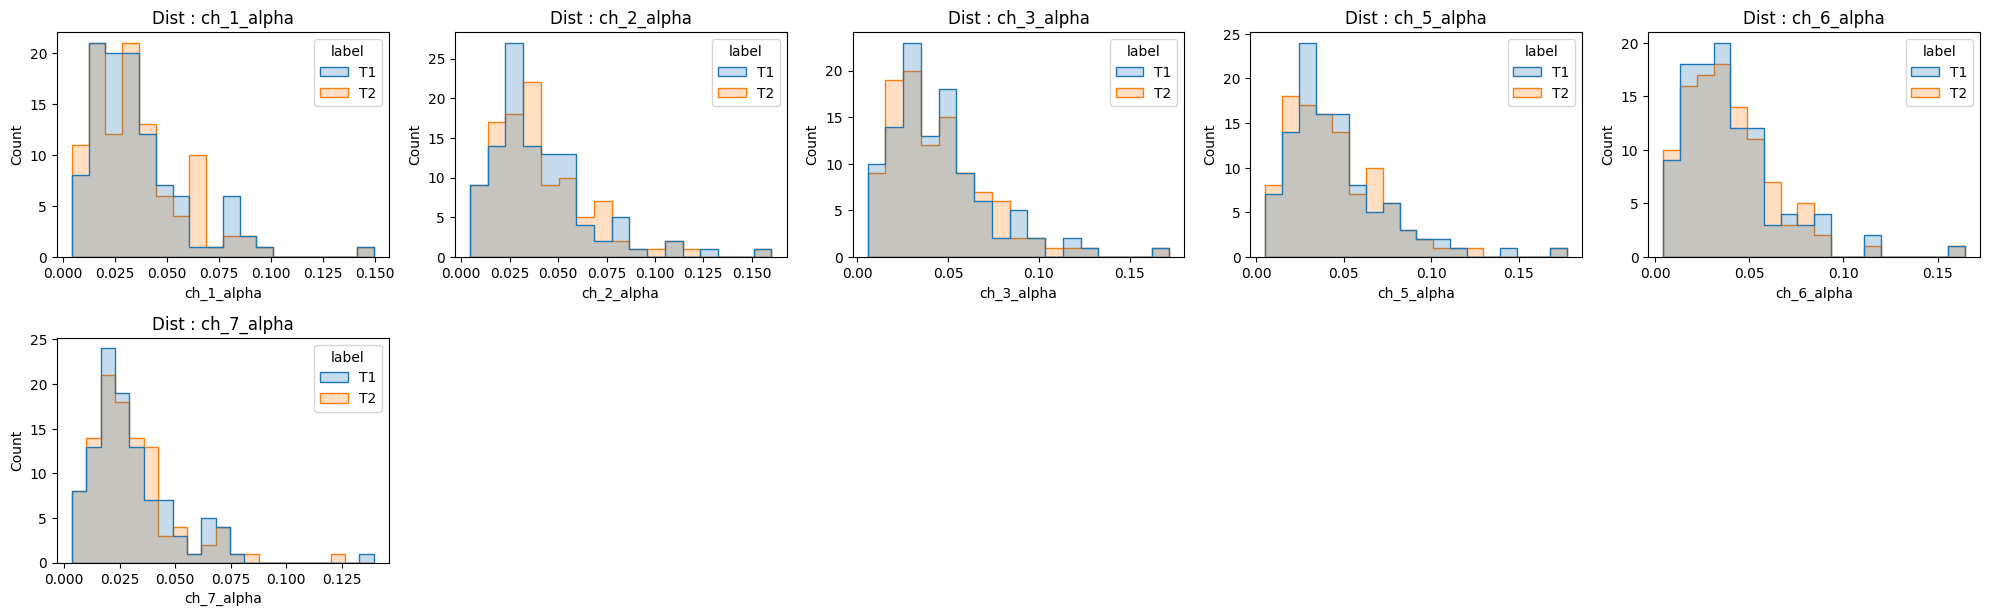

=========================== Joint - Region 1 - beta =============================


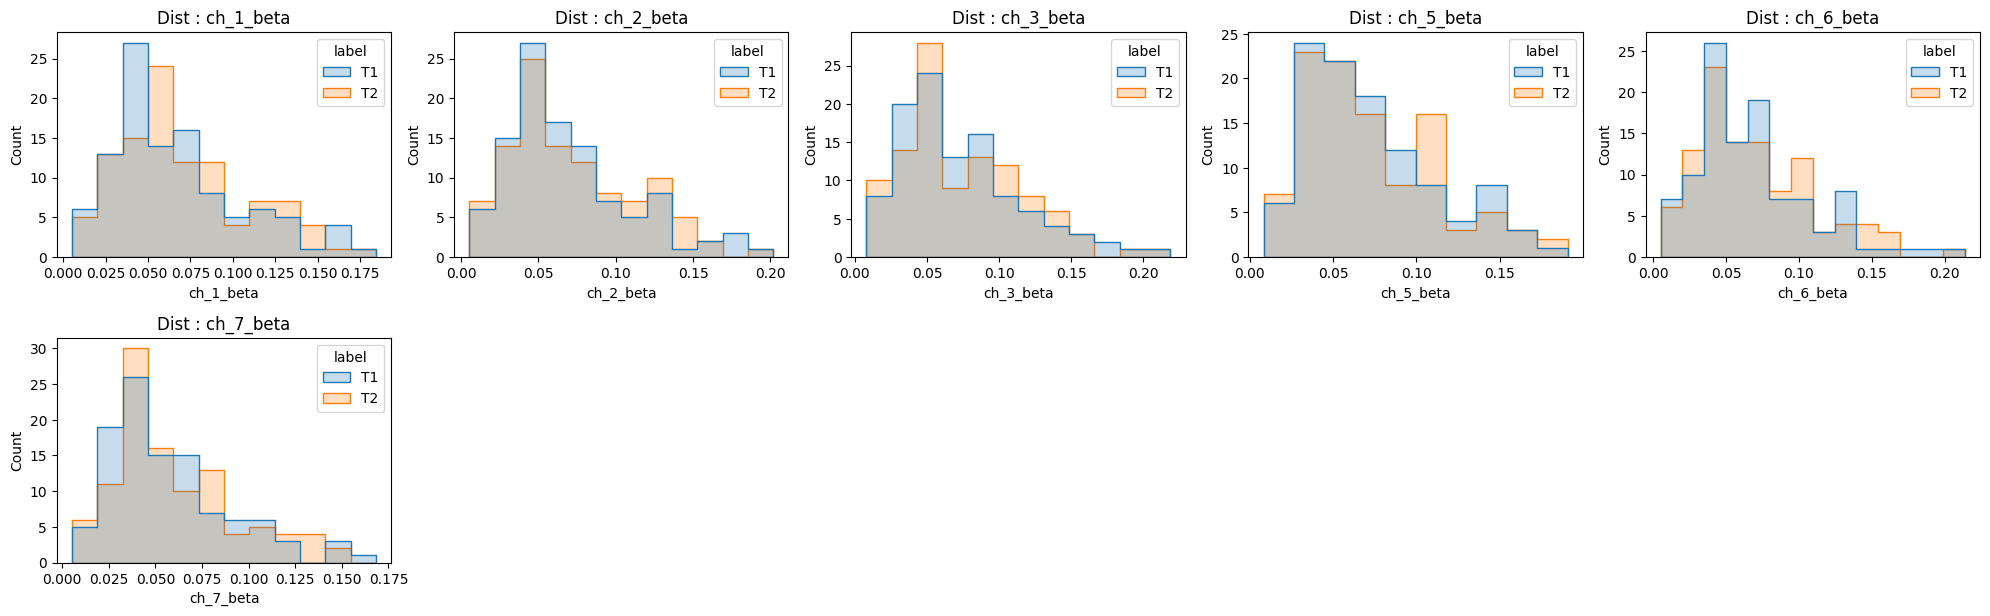

=========================== Joint - Region 1 - gamma =============================


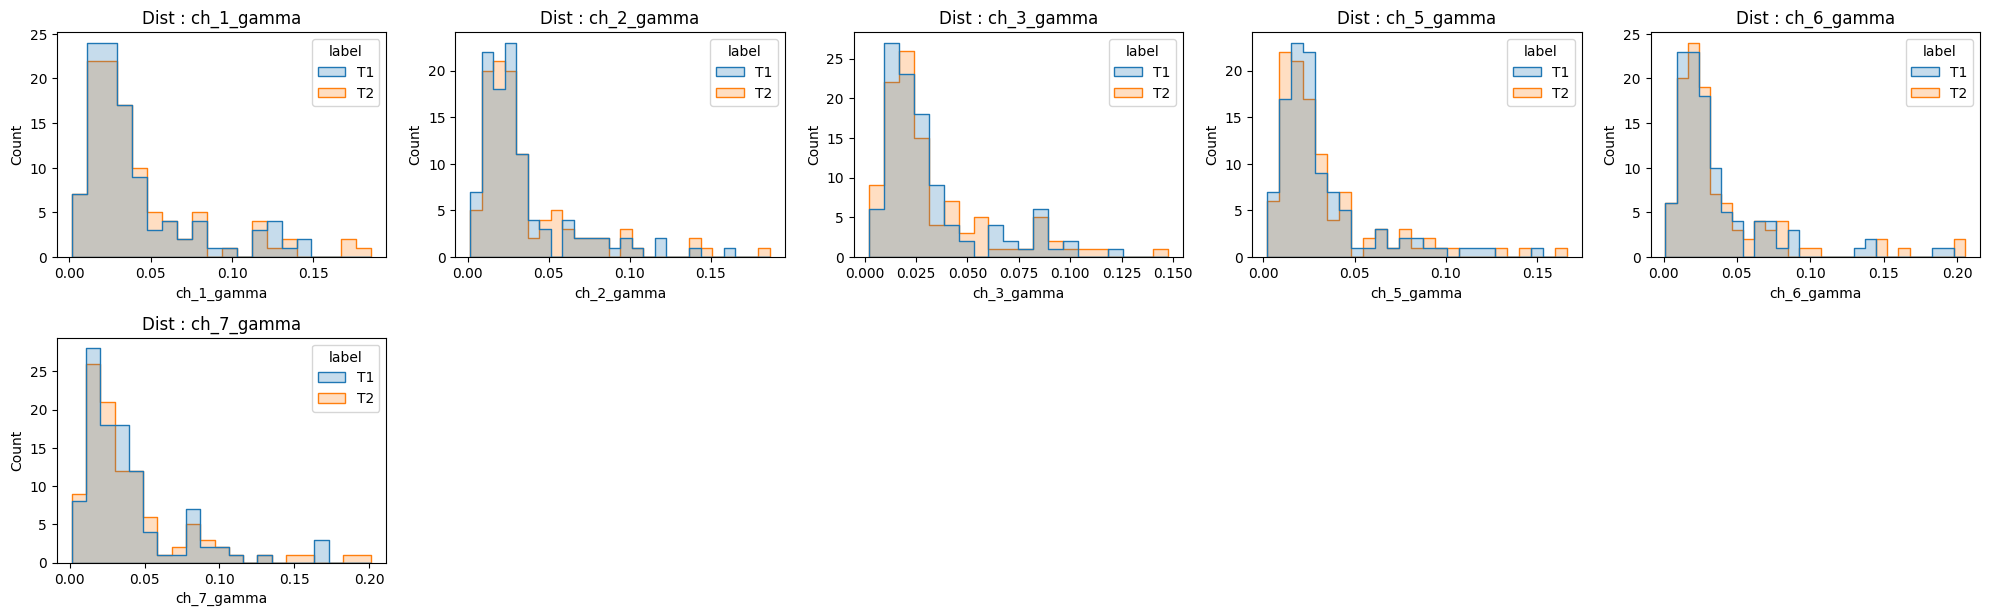

=========================== Joint - Region 1 - total =============================


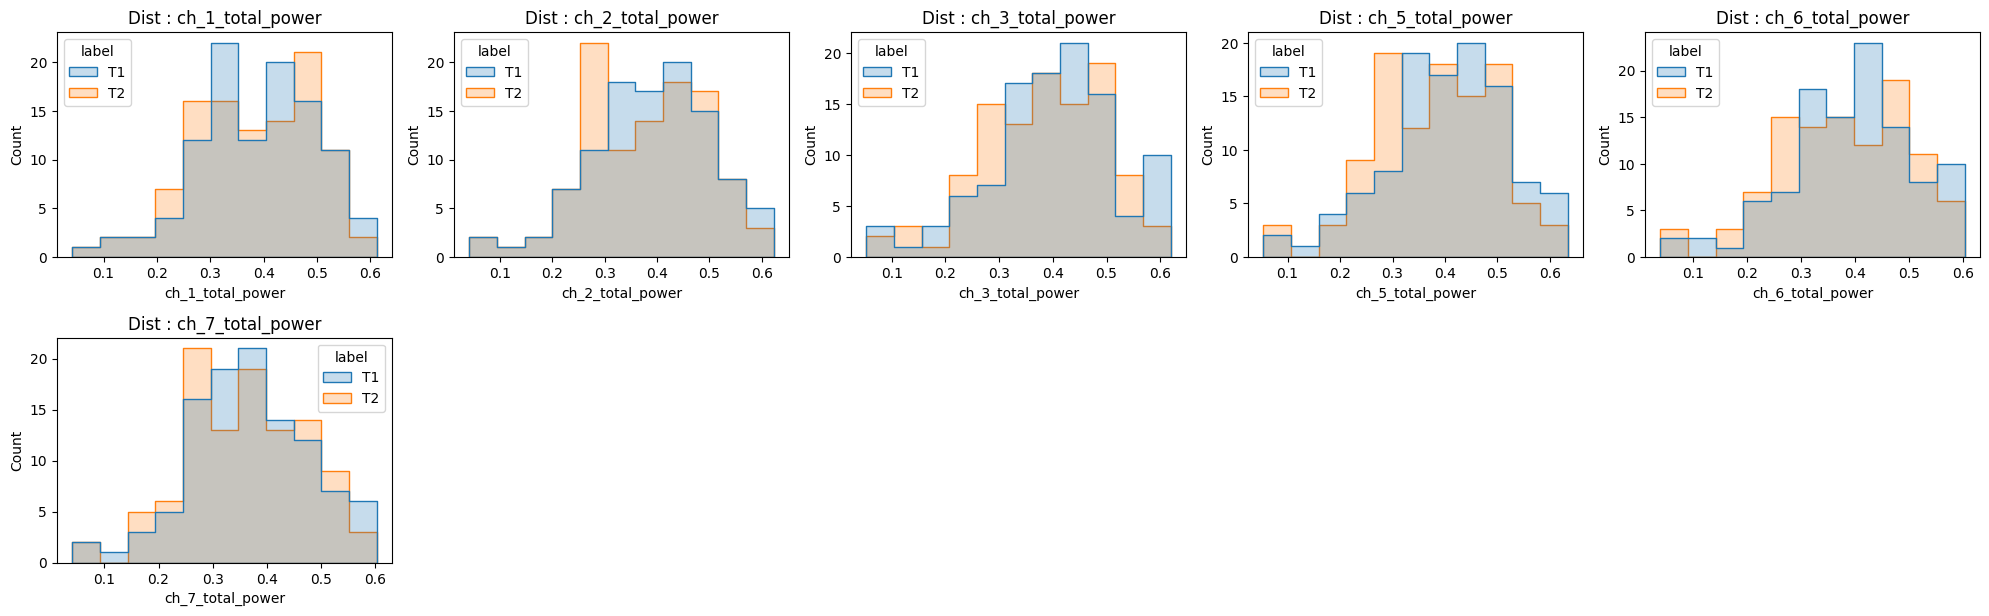

=========================== Joint - Region 1 - centroid =============================


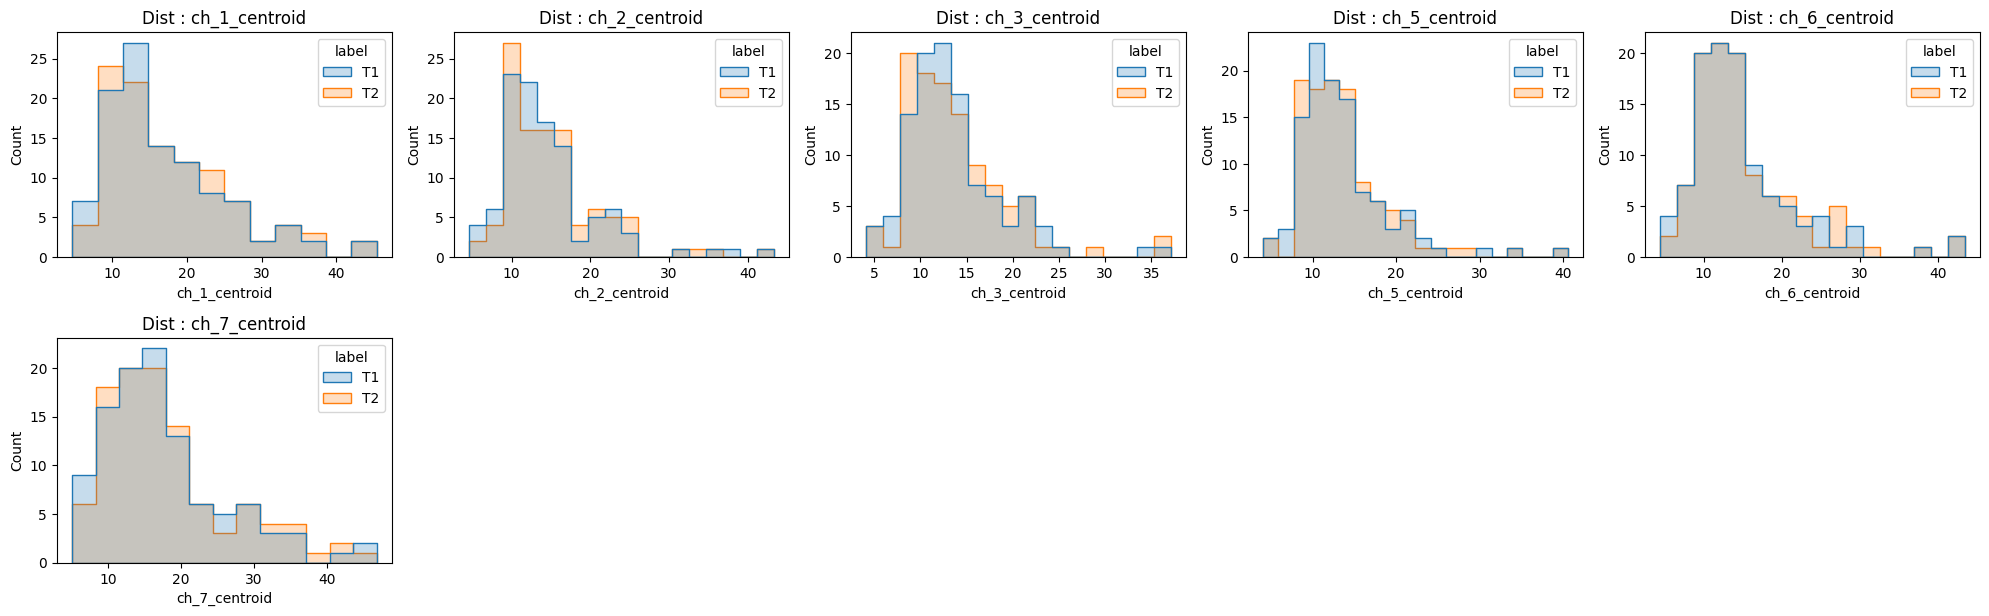

=========================== Joint - Region 1 - spread =============================


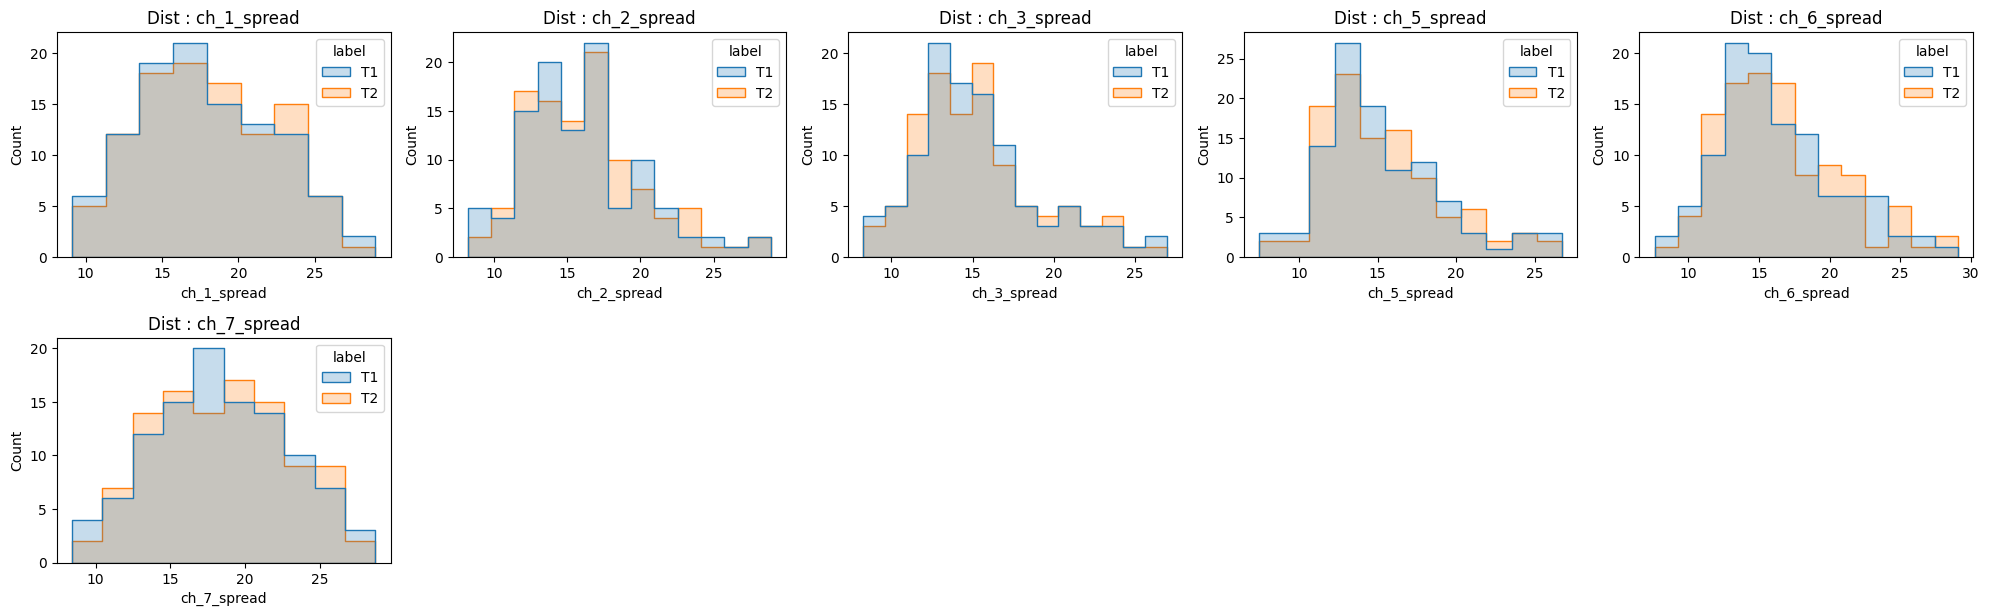

=========================== Joint - Region 1 - entropy =============================


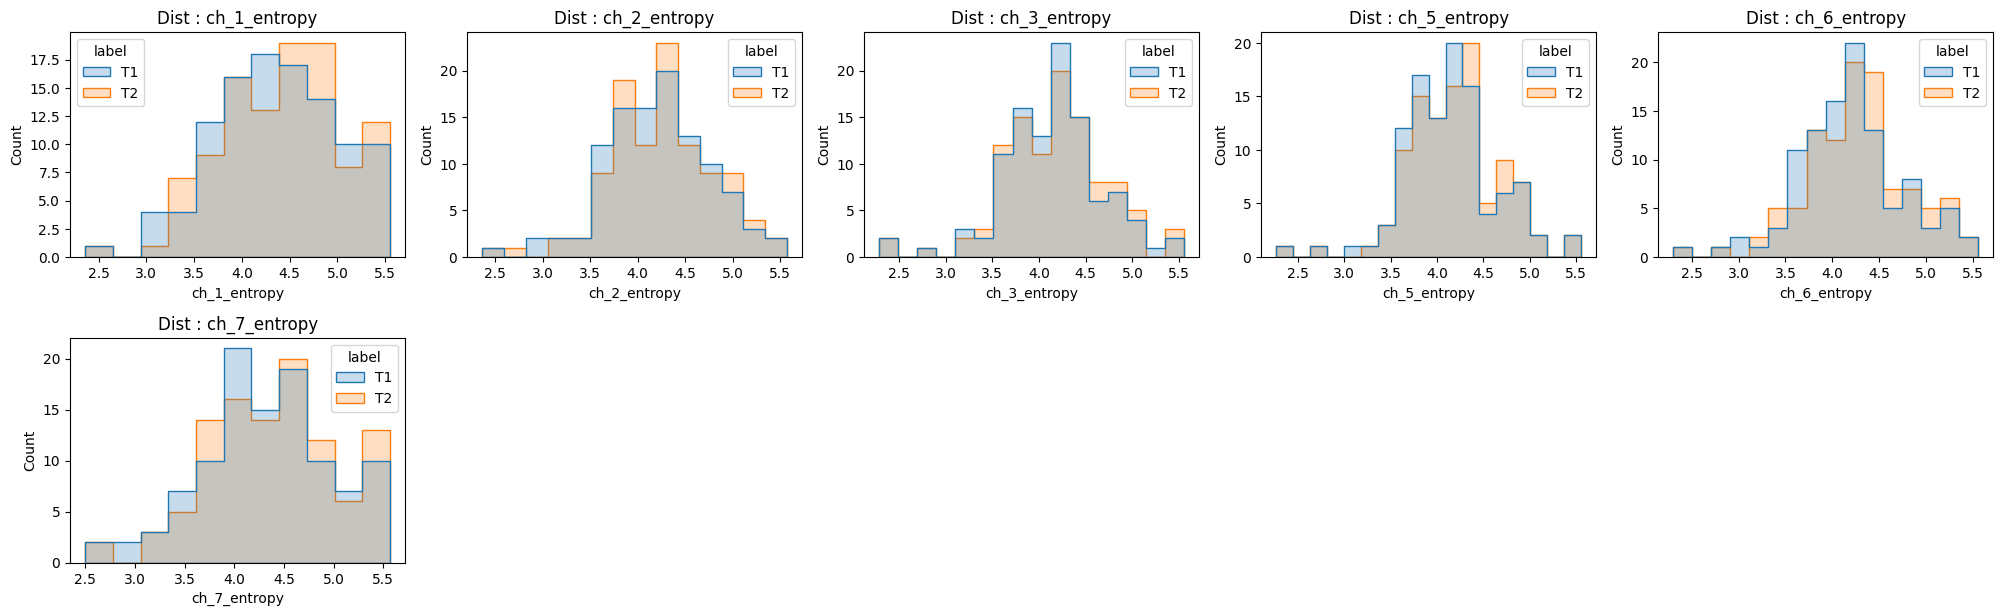

=========================== Joint - Region 1 - peak =============================


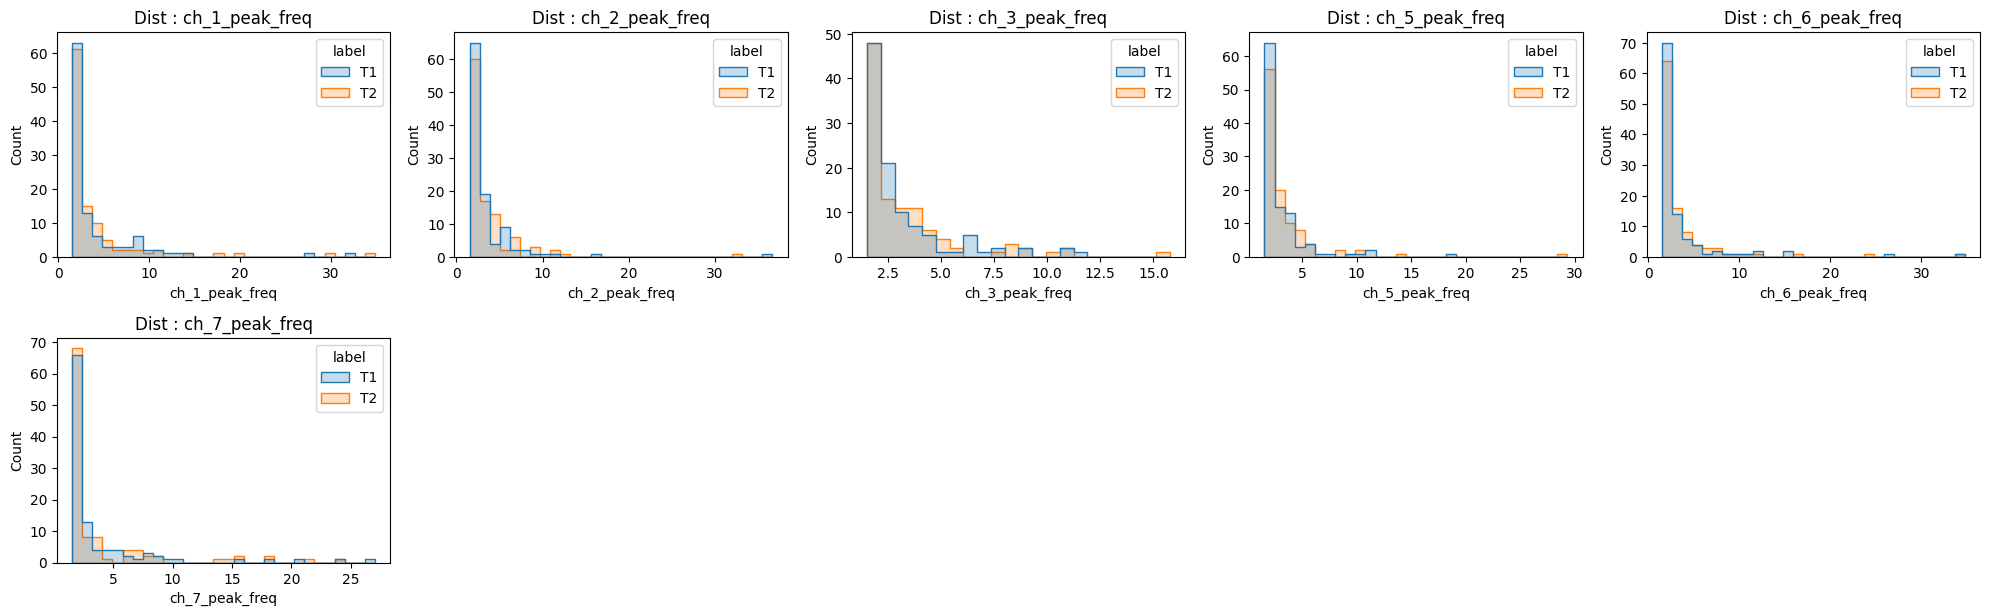

In [39]:
joint_agg_type = channel_info[channel_info["FeatureCategory"].isin(["Frequency"])]["AggType"].unique().tolist()
for i in joint_agg_type:
    feature_category = ["Frequency"]
    region_focus = region_of_interest["Region1"]
    agg = [i]
    cols_conc = (channel_info[(channel_info["FeatureCategory"].isin(feature_category)) &
                                (channel_info["AggType"].isin(agg)) &
        (channel_info["Region"].isin(region_focus))]["ColumnNames"].to_list())
    cols_conc = cols_conc + ["label"]
    print(f"=========================== Joint - Region 1 - {i} =============================")
    plot_distributions(data = data, cols_conc= cols_conc, nrows= 5, ncols=5)
    plt.show()
    

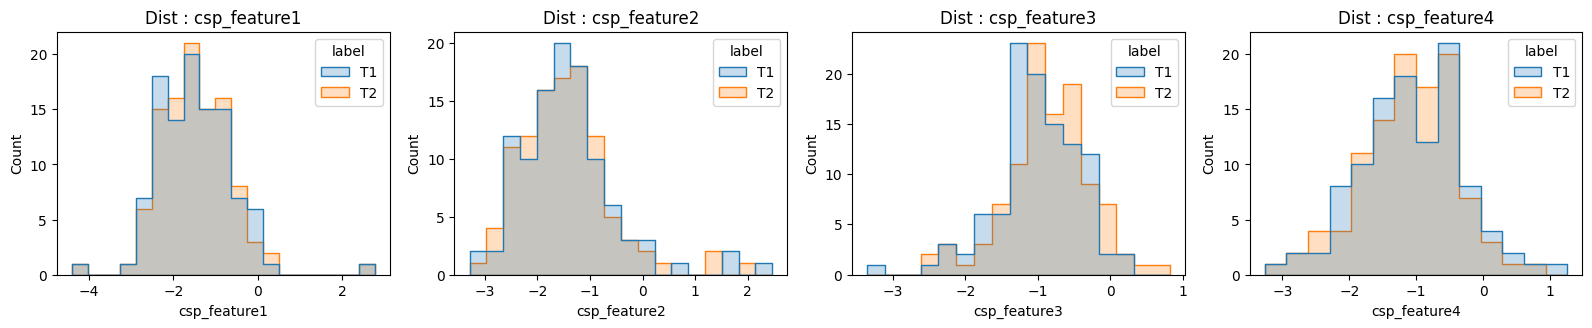

In [40]:
cols_conc = ["csp_feature1", "csp_feature2", "csp_feature3", "csp_feature4"]+ ["label"]
plot_distributions(data = data, cols_conc= cols_conc, nrows= 5, ncols=5)